# Biohub Cell Tracking: Data Model, EDA, and a Classical Baseline

## Problem Statement

The input is a short 3D time-lapse microscopy sequence

$$
I_t(z,y,x), \quad t = 0, \ldots, T-1,
$$

where fluorescently labelled cells appear as bright 3D structures. The target output is a directed tracking graph

$$
G = (V, E).
$$

Each node $v \in V$ is a cell detection with attributes

$$
(t_v, z_v, y_v, x_v),
$$

and each directed edge $(u,v) \in E$ links a cell at time $t$ to its continuation or daughter at a later time. A cell division is represented by one source node with two or more outgoing edges.

## Scientific Context

The biological task is lineage reconstruction during development. In light-sheet and related 3D microscopy, embryos can be imaged over time with cellular or nuclear fluorescence. The resulting movies contain dense populations of similar-looking cells that move, deform, enter or leave the field of view, and divide. Manual lineage tracing is slow and difficult to reproduce, so the computational goal is to infer a graph that preserves cell identity and mitotic branching over time.

The useful modeling separation is:

$$
I_t(z,y,x)
\;\longrightarrow\;
\widehat V_{\mathrm{cells}}
\;\longrightarrow\;
\widehat E_{\mathrm{links}}
\;\longrightarrow\;
\widehat L_{\mathrm{lineage}}.
$$

In words: the image sequence produces cell detections, detections are connected into temporal edges, and those edges define the lineage structure. The training annotations contain sparse centroid-level graph labels rather than dense segmentation masks. Therefore, unlabeled image regions must not be interpreted as background.

## Image Data Contract

Each `.zarr` directory stores one array at path `0/`.

```text
0/                    array path
0/zarr.json           metadata: shape, data_type, codecs
0/c/{t}/0/0/0         compressed chunk for timepoint t
shape                 usually (T, Z, Y, X) = (100, 64, 256, 256)
data_type             usually uint16
```

The chunk shape is one full timepoint:

$$
(1, Z, Y, X).
$$

Thus a frame can be streamed independently without loading the full video.

The physical voxel scale is anisotropic:

$$
(s_z, s_y, s_x) = (1.625, 0.40625, 0.40625)\ \mu m / \text{voxel}.
$$

This means the axial spacing is approximately four times coarser than the lateral spacing.

## Ground-Truth Graph Contract

Training labels are stored as `.geff` graph directories. They contain node IDs, node properties, and edge IDs:

```text
nodes/ids
nodes/props/t/values
nodes/props/z/values
nodes/props/y/values
nodes/props/x/values
edges/ids             source_id, target_id
```

The labels are sparse. A missing annotation does not imply a missing cell. The metadata field `estimated_number_of_nodes`, when present, estimates the total number of real cells in the sample and is useful for count calibration.

## Metric Geometry

Predicted and ground-truth nodes are matched per timepoint using physical distance. For two centroids $p=(z,y,x)$ and $q=(z,y,x)$, the distance is

$$
d(p,q)=\sqrt{((z_p-z_q)s_z)^2+((y_p-y_q)s_y)^2+((x_p-x_q)s_x)^2}.
$$

A match is allowed only when

$$
d(p,q) \le 7.0\ \mu m.
$$

In voxel units this is approximately

$$
7/1.625 \approx 4.3\ \text{Z slices}, \quad 7/0.40625 \approx 17.2\ \text{pixels in X/Y}.
$$

Therefore preserving Z precision is more important than preserving exact lateral pixel precision.

Let $m(\hat v)$ be the ground-truth node matched to predicted node $\hat v$, when such a match exists. A predicted edge is a true positive only when both endpoints match and the corresponding ground-truth edge exists:

$$
(\hat u,\hat v)\in \hat E \text{ is TP}
\quad \Longleftrightarrow \quad
(m(\hat u),m(\hat v))\in E^*.
$$

The edge term is Jaccard-like:

$$
J_E = \frac{TP_E}{TP_E+FP_E+FN_E},
$$

with an additional adjustment for over-predicting the total number of nodes. Division detection is also Jaccard-like:

$$
J_D = \frac{TP_D}{TP_D+FP_D+FN_D}.
$$

The practical consequence is that detection quality is upstream of tracking quality. A crude but useful approximation is

$$
R_{edge} \approx R_{node}^2 Q_{link},
$$

because an edge can be correct only if both endpoint cells are detected and the temporal association is correct.

## Baseline Model

This baseline is deliberately classical and interpretable. It preserves full Z resolution and average-pools X/Y by $r=4$:

$$
J_t(z,\bar y,\bar x)=\frac{1}{r^2}\sum_{i=0}^{r-1}\sum_{j=0}^{r-1} I_t(z,r\bar y+i,r\bar x+j).
$$

The resulting working scale is approximately isotropic:

$$
(s_z, r s_y, r s_x)=(1.625,1.625,1.625)\ \mu m.
$$

A Gaussian-smoothed working volume $S_t$ is thresholded with a robust intensity rule:

$$
\theta_{rel}=P_{50}(S_t)+\alpha\left(P_{99.8}(S_t)-P_{50}(S_t)\right),
$$

$$
\theta=\max(\theta_{Otsu},\theta_{rel}).
$$

Local maxima above $\theta$ become centroid candidates. Adjacent frames are linked with a Hungarian assignment using physical distance costs:

$$
C_{ij}=\begin{cases}
\lVert (p_i-q_j)\odot s\rVert_2, & \lVert (p_i-q_j)\odot s\rVert_2 \le d_{max},\\
\infty, & \text{otherwise}.
\end{cases}
$$

The optional division pass adds a second outgoing edge only when an unmatched current detection is close to a parent that already has one child and both daughters continue into the next frame when `DIV_REQUIRE_CONTINUED=True`. The important knobs are exposed in `CONFIG` so detection density, linking radius, and division behavior can be changed without editing the logic.


## Analysis Flow

The workflow follows the dependency structure of the graph metric. Node detection is inspected before linking, linking geometry is inspected before divisions, and the CSV writer is checked last because the graph file is the final interface.

| section | purpose |
|---|---|
| Data contract and configuration | Fix voxel scale, matching gate, row schema, and runtime switches. |
| Metric mental model | Visualize why node recall, count density, and link quality must be tuned together. |
| Metric-oriented metadata EDA | Check sample grouping, array geometry, embryo identity, and estimated node counts. |
| Ground-truth graph EDA | Inspect sparse graph density, physical edge motion, edge time gaps, and division geometry. |
| Classical baseline | Detect centroids from near-isotropic working grids, refine positions, suppress duplicates, and link frames. |
| Visual diagnostics | Overlay detections and links on real frames to expose threshold, depth, and association failure modes. |
| Detection calibration proxy | Compare detection density and sparse one-to-one recall across embryo-diverse samples. |
| Output graph construction | Stream per-dataset nodes and edges into the required CSV format. |
| Submission audit | Verify schema, sentinel values, coordinate bounds, and edge references before the file is used. |


## Submission Variant

`sub5_tight_isolated_pruning`: Tight link profile plus isolated-node pruning. Tests whether the small pruning gain from submission 2 combines with the strong tight-gate gain from submission 4.


In [1]:
from __future__ import annotations

import csv
import json
import os
import time
from collections import Counter
from dataclasses import asdict, dataclass
from pathlib import Path

try:
    import blosc2
except ImportError:
    blosc2 = None

try:
    import zarr
except ImportError:
    zarr = None

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.ndimage import gaussian_filter, maximum_filter
from scipy.optimize import linear_sum_assignment
from scipy.spatial import cKDTree
from scipy.spatial.distance import cdist

try:
    from skimage.feature import peak_local_max
except Exception:
    peak_local_max = None

try:
    from skimage.filters import threshold_otsu
except Exception:
    threshold_otsu = None


@dataclass
class CONFIG:
    # --- paths ---
    TRAIN_DIR: str = '/kaggle/input/competitions/biohub-cell-tracking-during-development/train'
    TEST_DIR: str = '/kaggle/input/competitions/biohub-cell-tracking-during-development/test'
    SAMPLE_SUBMISSION: str = '/kaggle/input/competitions/biohub-cell-tracking-during-development/sample_submission.csv'

    # --- experiment identity ---
    EXPERIMENT_TAG: str = 'sub5_tight_isolated_pruning'
    WRITE_EXPERIMENT_LOG: bool = False

    # --- fixed metric geometry ---
    SCALE: tuple[float, float, float] = (1.625, 0.40625, 0.40625)  # z,y,x um/voxel
    MATCH_GATE_UM: float = 7.0

    # --- peak detection on a near-isotropic working grid ---
    DETECTION_MODE: str = 'single'  # {'single', 'multiscale'}
    XY_DS: int = 4
    SMOOTH_SIGMA: float = 1.0
    MIN_PEAK_DIST: int = 2
    THRESH_REL: float = 0.20
    THRESH_PERCENTILE: float = 92.0
    THRESH_HI_PERCENTILE: float = 99.8
    USE_PERCENTILE_FLOOR: bool = False

    # --- centroid refinement and duplicate/weak-peak controls ---
    USE_CENTROID_REFINEMENT: bool = True
    REFINE_RADIUS_Z: int = 2
    REFINE_RADIUS_YX: int = 5
    REFINE_BG_PERCENTILE: float = 20.0
    MIN_REL_CONTRAST: float = 0.08
    EMPTY_FRAME_RESCUE_TOPK: int = 0
    USE_PHYSICAL_NMS: bool = True
    NMS_RADIUS_UM: float = 2.65
    USE_BORDER_FILTER: bool = True
    BORDER_Z: int = 1
    BORDER_YX: int = 2
    BORDER_KEEP_QUANTILE: float = 0.70
    USE_COUNT_STABILIZER: bool = True
    MAX_FRAME_COUNT_MULT: float = 1.70
    MAX_FRAME_COUNT_ADD: int = 45

    # --- multiscale candidate detector ---
    SMOOTH_SIGMAS: tuple[float, ...] = (0.75, 1.0, 1.35)
    THRESH_REL_GRID: tuple[float, ...] = (0.10, 0.15, 0.20, 0.25, 0.30)
    CANDIDATE_MIN_PEAK_DIST: int = 1
    FINAL_NMS_RADIUS_UM: float = 3.0
    NORM_LOW_PERCENTILE: float = 1.0
    NORM_HIGH_PERCENTILE: float = 99.8
    BG_SUBTRACT_SIGMA: float = 0.0

    # --- frame-level count control ---
    USE_TOPK_COUNT_CONTROL: bool = False
    TOPK_PER_FRAME: int | None = None
    TOPK_MULTIPLIER: float = 1.0
    MIN_NODES_PER_FRAME: int = 1
    MAX_NODES_PER_FRAME: int = 20000

    # --- linking ---
    MAX_LINK_DIST: float = 12.0
    USE_MOTION_COST: bool = False
    MOTION_LAMBDA: float = 0.25
    TIGHT_LINK_PROFILE: bool = True
    TIGHT_MAX_LINK_DIST: float = 11.0

    # --- optional skip-frame links ---
    USE_GAP_LINKS: bool = False
    MAX_GAP: int = 2
    GAP_LINK_DIST_PER_FRAME: float = 12.0

    # --- divisions ---
    DETECT_DIVISIONS: bool = True
    DIV_PARENT_DIST: float = 12.0
    DIV_SISTER_DIST: float = 7.0
    DIV_REQUIRE_CONTINUED: bool = True
    DIV_USE_MIDPOINT: bool = False
    DIV_MIDPOINT_DIST: float = 7.0
    USE_DIV_COUNT_GAIN_GATE: bool = True
    DIV_MIN_COUNT_GAIN: int = 1
    TIGHT_DIV_PARENT_DIST: float = 8.75
    TIGHT_DIV_SISTER_DIST: float = 6.25

    # --- optional isolated-node pruning ---
    PRUNE_ISOLATED_NODES: bool = True
    KEEP_STRONG_ISOLATED: bool = False
    STRONG_ISOLATED_QUANTILE: float = 0.97

    # --- runtime controls ---
    SUBMIT_MODE: bool = True
    EDA_SAMPLE_LIMIT: int = 25
    GT_EDA_SAMPLE_LIMIT: int = 8
    COUNT_CALIBRATION_SAMPLE_LIMIT: int = 5
    COUNT_SWEEP_FRAMES: int = 5
    LOCAL_PROXY_SAMPLE_LIMIT: int = 3
    RUN_BASIC_EDA: bool | None = True
    RUN_GT_EDA: bool | None = True
    RUN_VISUAL_EDA: bool | None = True
    RUN_COUNT_SWEEP: bool | None = True
    RUN_LOCAL_PROXY: bool | None = True
    RUN_SUBMISSION_DISPLAY: bool | None = True
    RUN_SUBMISSION_PLOTS: bool | None = True
    SUBMISSION_LIMIT: int | None = None
    TIME_BUDGET_S: int = 11 * 3600
    CV_SPLITS: int = 5
    OFFLINE_EVAL_LIMIT: int = 6
    RUN_OFFLINE_EVAL: bool = False
    DIV_FRAME_BUFFER: int = 2
    RANDOM_STATE: int = 0

    def __post_init__(self) -> None:
        if self.RUN_BASIC_EDA is None:
            self.RUN_BASIC_EDA = not self.SUBMIT_MODE
        if self.RUN_GT_EDA is None:
            self.RUN_GT_EDA = not self.SUBMIT_MODE
        if self.RUN_VISUAL_EDA is None:
            self.RUN_VISUAL_EDA = not self.SUBMIT_MODE
        if self.RUN_COUNT_SWEEP is None:
            self.RUN_COUNT_SWEEP = not self.SUBMIT_MODE
        if self.RUN_LOCAL_PROXY is None:
            self.RUN_LOCAL_PROXY = not self.SUBMIT_MODE
        if self.RUN_SUBMISSION_DISPLAY is None:
            self.RUN_SUBMISSION_DISPLAY = not self.SUBMIT_MODE
        if self.RUN_SUBMISSION_PLOTS is None:
            self.RUN_SUBMISSION_PLOTS = self.RUN_SUBMISSION_DISPLAY


CFG = CONFIG()

# Backward-compatible aliases used by lightweight cells below.
SCALE = np.array(CFG.SCALE, dtype=np.float64)
XY_DS = CFG.XY_DS
SMOOTH_SIGMA = CFG.SMOOTH_SIGMA
MIN_PEAK_DIST = CFG.MIN_PEAK_DIST
THRESH_REL = CFG.THRESH_REL
THRESH_PERCENTILE = CFG.THRESH_PERCENTILE
THRESH_HI_PERCENTILE = CFG.THRESH_HI_PERCENTILE
USE_PERCENTILE_FLOOR = CFG.USE_PERCENTILE_FLOOR
MAX_LINK_DIST = CFG.MAX_LINK_DIST
DETECT_DIVISIONS = CFG.DETECT_DIVISIONS
DIV_PARENT_DIST = CFG.DIV_PARENT_DIST
DIV_SISTER_DIST = CFG.DIV_SISTER_DIST
SUBMIT_MODE = CFG.SUBMIT_MODE
EDA_SAMPLE_LIMIT = CFG.EDA_SAMPLE_LIMIT
GT_EDA_SAMPLE_LIMIT = CFG.GT_EDA_SAMPLE_LIMIT
COUNT_CALIBRATION_SAMPLE_LIMIT = CFG.COUNT_CALIBRATION_SAMPLE_LIMIT
COUNT_SWEEP_FRAMES = CFG.COUNT_SWEEP_FRAMES
RUN_BASIC_EDA = CFG.RUN_BASIC_EDA
RUN_GT_EDA = CFG.RUN_GT_EDA
RUN_VISUAL_EDA = CFG.RUN_VISUAL_EDA
RUN_COUNT_SWEEP = CFG.RUN_COUNT_SWEEP
RUN_LOCAL_PROXY = CFG.RUN_LOCAL_PROXY
RUN_SUBMISSION_DISPLAY = CFG.RUN_SUBMISSION_DISPLAY
RUN_SUBMISSION_PLOTS = CFG.RUN_SUBMISSION_PLOTS
SUBMISSION_LIMIT = CFG.SUBMISSION_LIMIT


In [2]:
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 9,
    'axes.titlesize': 10,
    'axes.labelsize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

PLOT_COLORS = {
    'blue': '#3366AA',
    'green': '#2E8B57',
    'red': '#B4473A',
    'purple': '#6A4C93',
    'orange': '#C77C2E',
    'gray': '#6B7280',
    'light': '#D8DEE9',
}


def short_label(value, max_len: int = 22) -> str:
    text = str(value)
    return text if len(text) <= max_len else text[:max_len - 1] + '…'


def style_axis(ax, title: str | None = None, xlabel: str | None = None, ylabel: str | None = None, grid_axis: str = 'y') -> None:
    if title:
        ax.set_title(title, pad=8)
    if xlabel:
        ax.set_xlabel(xlabel)
    if ylabel:
        ax.set_ylabel(ylabel)
    if grid_axis:
        ax.grid(True, axis=grid_axis, alpha=0.22, linewidth=0.7)
    ax.tick_params(axis='both', length=3, width=0.8)


def annotate_bars(ax, bars, fmt='{:.0f}', dy: float = 2.0) -> None:
    for bar in bars:
        height = bar.get_height()
        if np.isfinite(height):
            ax.annotate(
                fmt.format(height),
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, dy),
                textcoords='offset points',
                ha='center',
                va='bottom',
                fontsize=8,
            )


def hide_axis(ax, message: str = 'No data') -> None:
    ax.axis('off')
    ax.text(0.5, 0.5, message, ha='center', va='center', color=PLOT_COLORS['gray'], fontsize=9)


In [3]:
def find_data_root() -> Path | None:
    local_root = os.environ.get('BIOHUB_DATA_ROOT')
    candidates = [Path(local_root)] if local_root else []
    candidates.extend([
        Path(CFG.TEST_DIR).parent,
        Path('/kaggle/input/biohub-cell-tracking-during-development'),
        Path.cwd(),
        Path.cwd().parent,
        Path.cwd() / 'data',
        Path.cwd().parent / 'data',
    ])
    for root in candidates:
        if (root / 'test').is_dir() or (root / 'train').is_dir():
            return root

    kaggle_input = Path('/kaggle/input')
    if kaggle_input.is_dir():
        for test_dir in kaggle_input.glob('**/test'):
            if list(test_dir.glob('*.zarr')):
                return test_dir.parent
    return None


DATA_ROOT = find_data_root()
TRAIN_DIR = DATA_ROOT / 'train' if DATA_ROOT else None
TEST_DIR = DATA_ROOT / 'test' if DATA_ROOT else None
SAMPLE_SUBMISSION_PATH = DATA_ROOT / 'sample_submission.csv' if DATA_ROOT else Path(CFG.SAMPLE_SUBMISSION)

path_status = pd.DataFrame([
    {'item': 'data_root_found', 'value': DATA_ROOT is not None},
    {'item': 'train_dir_found', 'value': bool(TRAIN_DIR and TRAIN_DIR.is_dir())},
    {'item': 'test_dir_found', 'value': bool(TEST_DIR and TEST_DIR.is_dir())},
    {'item': 'sample_submission_found', 'value': SAMPLE_SUBMISSION_PATH.exists()},
])
display(path_status)


,item,value
0,data_root_found,True
1,train_dir_found,True
2,test_dir_found,True
3,sample_submission_found,True


,item,value
0,task,"3D+time cell centroid detection, tracking, and..."
1,image array,"Zarr v3, path 0/, shape (T, Z, Y, X)"
2,chunk layout,one timepoint per chunk: 0/c/{t}/0/0/0
3,voxel scale,"z=1.625, y=x=0.40625 um/voxel"
4,matching radius,7.0 um physical distance
5,output schema,CSV graph rows: node + edge


,parameter,value
0,SUBMIT_MODE,True
1,SCALE,"(1.625, 0.40625, 0.40625)"
2,MATCH_GATE_UM,7.0
3,DETECTION_MODE,single
4,XY_DS,4
5,SMOOTH_SIGMA,1.0
6,MIN_PEAK_DIST,2
7,THRESH_REL,0.2
8,USE_CENTROID_REFINEMENT,True
9,REFINE_RADIUS_Z,2


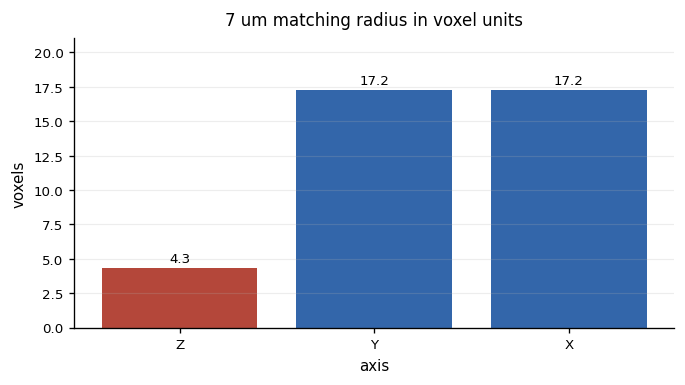

In [4]:
problem_contract = pd.DataFrame([
    ['task', '3D+time cell centroid detection, tracking, and division linking'],
    ['image array', 'Zarr v3, path 0/, shape (T, Z, Y, X)'],
    ['chunk layout', 'one timepoint per chunk: 0/c/{t}/0/0/0'],
    ['voxel scale', f'z={CFG.SCALE[0]}, y=x={CFG.SCALE[1]} um/voxel'],
    ['matching radius', f'{CFG.MATCH_GATE_UM} um physical distance'],
    ['output schema', 'CSV graph rows: node + edge'],
], columns=['item', 'value'])


visible_config_keys = [
    'SUBMIT_MODE', 'SCALE', 'MATCH_GATE_UM',
    'DETECTION_MODE', 'XY_DS', 'SMOOTH_SIGMA', 'MIN_PEAK_DIST', 'THRESH_REL',
    'USE_CENTROID_REFINEMENT', 'REFINE_RADIUS_Z', 'REFINE_RADIUS_YX',
    'USE_PHYSICAL_NMS', 'NMS_RADIUS_UM', 'USE_BORDER_FILTER', 'BORDER_KEEP_QUANTILE',
    'USE_COUNT_STABILIZER', 'MAX_FRAME_COUNT_MULT', 'MAX_FRAME_COUNT_ADD',
    'PRUNE_ISOLATED_NODES', 'KEEP_STRONG_ISOLATED',
    'SMOOTH_SIGMAS', 'THRESH_REL_GRID', 'CANDIDATE_MIN_PEAK_DIST', 'FINAL_NMS_RADIUS_UM',
    'USE_TOPK_COUNT_CONTROL', 'TOPK_PER_FRAME', 'MAX_LINK_DIST', 'TIGHT_LINK_PROFILE',
    'USE_MOTION_COST', 'MOTION_LAMBDA', 'DETECT_DIVISIONS', 'DIV_PARENT_DIST', 'DIV_SISTER_DIST', 'USE_DIV_COUNT_GAIN_GATE',
    'DIV_REQUIRE_CONTINUED', 'DIV_USE_MIDPOINT', 'DIV_MIDPOINT_DIST',
    'RUN_BASIC_EDA', 'RUN_GT_EDA', 'RUN_VISUAL_EDA', 'RUN_COUNT_SWEEP', 'RUN_LOCAL_PROXY',
    'RUN_SUBMISSION_DISPLAY', 'SUBMISSION_LIMIT', 'TIME_BUDGET_S', 'WRITE_EXPERIMENT_LOG',
]
config_summary = pd.DataFrame([
    {'parameter': k, 'value': getattr(CFG, k)}
    for k in visible_config_keys
])


display(problem_contract)

display(config_summary)


match_voxels = pd.DataFrame({
    'axis': ['Z', 'Y', 'X'],
    'voxels': [CFG.MATCH_GATE_UM / CFG.SCALE[0], CFG.MATCH_GATE_UM / CFG.SCALE[1], CFG.MATCH_GATE_UM / CFG.SCALE[2]],
})
fig, ax = plt.subplots(figsize=(5.6, 3.1), constrained_layout=True)
bars = ax.bar(match_voxels['axis'], match_voxels['voxels'], color=[PLOT_COLORS['red'], PLOT_COLORS['blue'], PLOT_COLORS['blue']])
annotate_bars(ax, bars, fmt='{:.1f}')
style_axis(ax, '7 um matching radius in voxel units', 'axis', 'voxels')
ax.set_ylim(0, max(match_voxels['voxels']) * 1.22)
plt.show()


## Metric Mental Model

The score is graph-based, but most early failure modes are caused by node detection. If a true temporal edge has two endpoints, both endpoints must be matched before the edge can become a true positive. This creates an approximate quadratic dependence on node recall:

$$
R_{edge} \approx R_{node}^2 Q_{link}.
$$

At the same time, emitting too many nodes can increase false edges and trigger node-count adjustment. The first tuning target is therefore not simply maximum recall; it is a stable balance between sparse recall and the count ratio

$$
\rho = \frac{\hat N}{N^{est}}.
$$


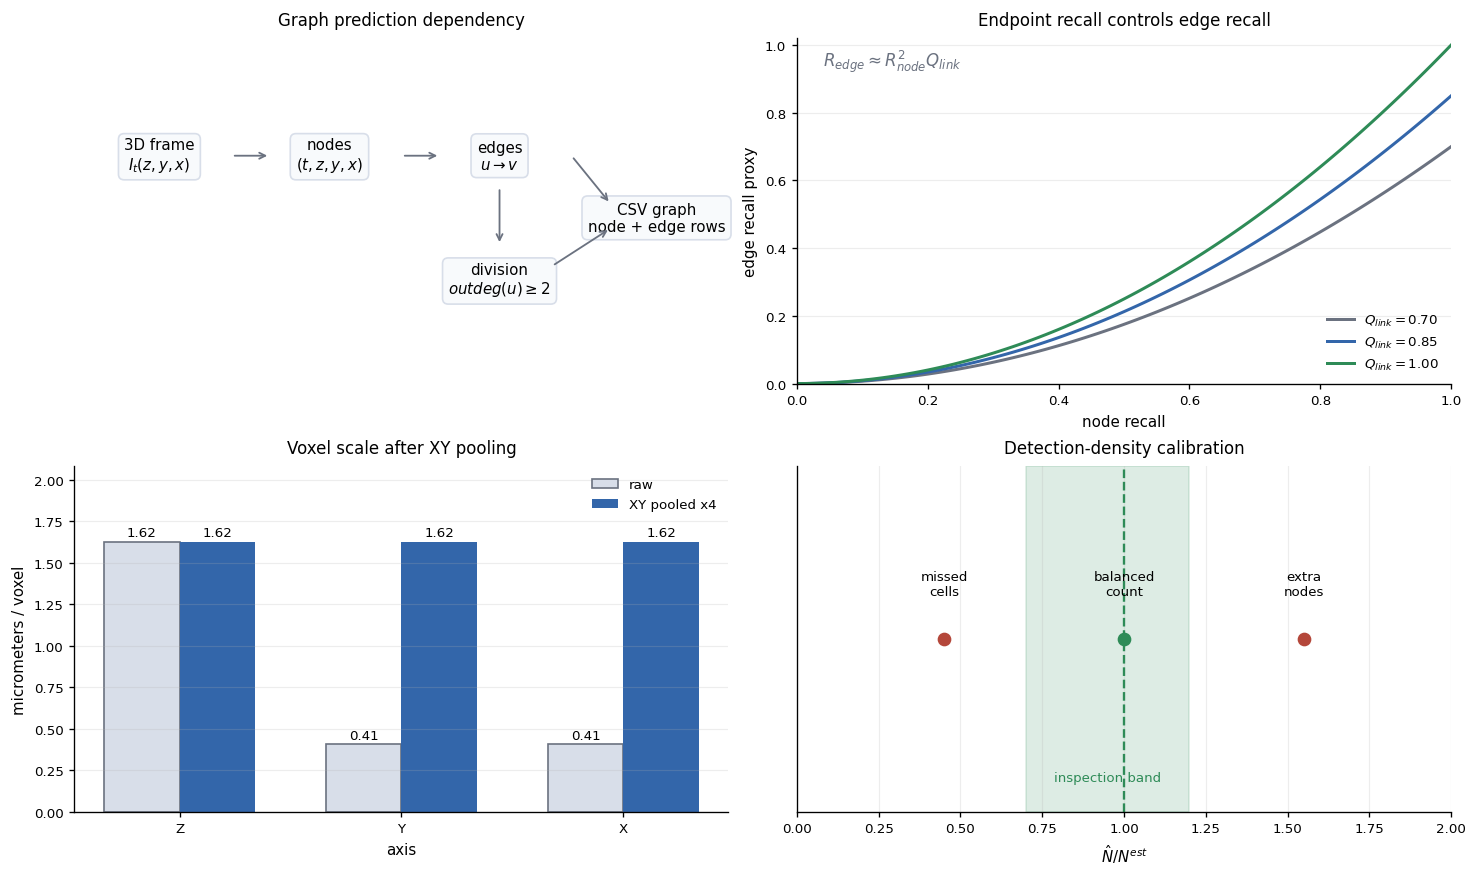

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12.2, 7.2), constrained_layout=True)
axes = axes.ravel()

# Panel 1: dependency diagram.
ax = axes[0]
ax.axis('off')
box_style = {'boxstyle': 'round,pad=0.38', 'facecolor': '#F8FAFC', 'edgecolor': PLOT_COLORS['light'], 'linewidth': 1.0}
items = [
    ('3D frame\n$I_t(z,y,x)$', (0.13, 0.66)),
    ('nodes\n$(t,z,y,x)$', (0.39, 0.66)),
    ('edges\n$u\\to v$', (0.65, 0.66)),
    ('division\n$outdeg(u)\\geq2$', (0.65, 0.30)),
    ('CSV graph\nnode + edge rows', (0.89, 0.48)),
]
for text, (x, y) in items:
    ax.text(x, y, text, ha='center', va='center', fontsize=9, bbox=box_style, transform=ax.transAxes)
for xy0, xy1 in [((0.24, 0.66), (0.30, 0.66)), ((0.50, 0.66), (0.56, 0.66)), ((0.76, 0.66), (0.82, 0.52)), ((0.73, 0.34), (0.82, 0.45)), ((0.65, 0.57), (0.65, 0.40))]:
    ax.annotate('', xy=xy1, xytext=xy0, xycoords='axes fraction', textcoords='axes fraction', arrowprops={'arrowstyle': '->', 'lw': 1.1, 'color': PLOT_COLORS['gray']})
ax.set_title('Graph prediction dependency', pad=8)

# Panel 2: node recall has quadratic leverage on edge recall.
ax = axes[1]
r = np.linspace(0, 1, 101)
for q, color in [(0.70, PLOT_COLORS['gray']), (0.85, PLOT_COLORS['blue']), (1.00, PLOT_COLORS['green'])]:
    ax.plot(r, (r ** 2) * q, color=color, linewidth=1.8, label=f'$Q_{{link}}={q:.2f}$')
ax.text(0.04, 0.92, r'$R_{edge} \approx R_{node}^2 Q_{link}$', transform=ax.transAxes, fontsize=10, color=PLOT_COLORS['gray'])
ax.legend(frameon=False, loc='lower right')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
style_axis(ax, 'Endpoint recall controls edge recall', 'node recall', 'edge recall proxy')

# Panel 3: raw anisotropic scale vs working grid scale.
ax = axes[2]
labels = ['Z', 'Y', 'X']
raw = np.array(CFG.SCALE)
working = raw.copy()
working[1:] *= CFG.XY_DS
x = np.arange(len(labels))
width = 0.34
b1 = ax.bar(x - width / 2, raw, width=width, color=PLOT_COLORS['light'], edgecolor=PLOT_COLORS['gray'], label='raw')
b2 = ax.bar(x + width / 2, working, width=width, color=PLOT_COLORS['blue'], label=f'XY pooled x{CFG.XY_DS}')
annotate_bars(ax, b1, fmt='{:.2f}', dy=1.5)
annotate_bars(ax, b2, fmt='{:.2f}', dy=1.5)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend(frameon=False)
ax.set_ylim(0, max(working) * 1.28)
style_axis(ax, 'Voxel scale after XY pooling', 'axis', 'micrometers / voxel')

# Panel 4: count-ratio calibration band.
ax = axes[3]
ax.set_xlim(0, 2.0)
ax.set_ylim(0, 1)
ax.axvspan(0.7, 1.2, color=PLOT_COLORS['green'], alpha=0.16)
ax.axvline(1.0, color=PLOT_COLORS['green'], linestyle='--', linewidth=1.4)
points = [(0.45, 'missed\ncells'), (1.0, 'balanced\ncount'), (1.55, 'extra\nnodes')]
for x0, label in points:
    ax.scatter([x0], [0.5], s=52, color=PLOT_COLORS['red'] if x0 != 1.0 else PLOT_COLORS['green'], zorder=3)
    ax.text(x0, 0.62, label, ha='center', va='bottom', fontsize=8)
ax.set_yticks([])
ax.text(0.95, 0.10, 'inspection band', ha='center', va='center', fontsize=8, color=PLOT_COLORS['green'])
style_axis(ax, 'Detection-density calibration', r'$\hat N/N^{est}$', None, grid_axis='x')
plt.show()


## Lightweight Metric-Oriented EDA

This section deliberately inspects only quantities that affect the graph metric or validation design:

| quantity | why it matters |
|---|---|
| sample and embryo counts | hidden evaluation is embryo-disjoint, so calibration should not rely on one embryo. |
| array geometry | determines whether one-frame streaming and Z-preserving detection are feasible. |
| estimated node count | anchors the detection-density ratio $\hat N/N^{est}$. |
| estimated nodes per frame | gives a scale for expected centroid density and runtime. |

Storage-size diagnostics are skipped because they do not determine matching, linking, division scoring, or node-count calibration.


In [6]:
def list_zarr_names(split_dir: Path | None) -> list[str]:
    if split_dir is None or not split_dir.is_dir():
        return []
    return sorted(p.name[:-5] for p in split_dir.glob('*.zarr'))


def embryo_id(name: str) -> str:
    return name.split('_')[0]


def select_diverse_samples(names: list[str], limit: int) -> list[str]:
    selected = []
    seen_embryos = set()
    for name in names:
        emb = embryo_id(name)
        if emb in seen_embryos:
            continue
        selected.append(name)
        seen_embryos.add(emb)
        if len(selected) >= limit:
            return selected
    for name in names:
        if name not in selected:
            selected.append(name)
            if len(selected) >= limit:
                break
    return selected


def sampled_frame_indices(T: int, n: int | None) -> np.ndarray:
    T = int(T)
    if T <= 0:
        return np.array([], dtype=np.int64)
    if n is None or int(n) >= T:
        return np.arange(T, dtype=np.int64)
    n = max(1, min(int(n), T))
    return np.unique(np.linspace(0, T - 1, n, dtype=np.int64))


def sampled_gt_frames(gt: pd.DataFrame, T: int, n: int | None) -> list[int]:
    frames = sorted(int(t) for t in gt['t'].unique() if 0 <= int(t) < int(T))
    if not frames:
        return []
    if n is None or int(n) >= len(frames):
        return frames
    idx = np.unique(np.linspace(0, len(frames) - 1, max(1, int(n)), dtype=np.int64))
    return [frames[int(i)] for i in idx]


def read_zarr_meta(zarr_path: Path) -> tuple[tuple[int, ...], np.dtype]:
    meta = json.loads((zarr_path / '0' / 'zarr.json').read_text())
    return tuple(meta['shape']), np.dtype(meta['data_type'])


def find_key_recursive(obj, key: str):
    if isinstance(obj, dict):
        if key in obj:
            return obj[key]
        for value in obj.values():
            hit = find_key_recursive(value, key)
            if hit is not None:
                return hit
    elif isinstance(obj, list):
        for value in obj:
            hit = find_key_recursive(value, key)
            if hit is not None:
                return hit
    return None


def read_estimated_nodes(geff_path: Path) -> float:
    meta_path = geff_path / 'zarr.json'
    if not meta_path.exists():
        return float('nan')
    try:
        meta = json.loads(meta_path.read_text())
        value = find_key_recursive(meta, 'estimated_number_of_nodes')
        return float(value) if value is not None else float('nan')
    except Exception:
        return float('nan')


def scan_split(split_dir: Path | None, limit: int = 25) -> pd.DataFrame:
    names = list_zarr_names(split_dir)[:limit]
    rows = []
    for name in names:
        zarr_path = split_dir / f'{name}.zarr'
        shape, _ = read_zarr_meta(zarr_path)
        est_nodes = read_estimated_nodes(split_dir / f'{name}.geff')
        rows.append({
            'name': name,
            'embryo': embryo_id(name),
            'T': shape[0],
            'Z': shape[1],
            'Y': shape[2],
            'X': shape[3],
            'estimated_number_of_nodes': est_nodes,
            'estimated_nodes_per_frame': est_nodes / shape[0] if np.isfinite(est_nodes) and shape[0] > 0 else np.nan,
        })
    return pd.DataFrame(rows)


,split,n_samples,n_embryos
0,train,199,2
1,test,4,2


visible train/test embryo overlap: ['44b6', '6bba'] count= 2
This can occur in the visible example split; it is logged but not treated as a failure.
train metric-oriented metadata


,name,embryo,T,Z,Y,X,estimated_number_of_nodes,estimated_nodes_per_frame
0,44b6_0113de3b,44b6,100,64,256,256,25755.0,257.55
1,44b6_0b24845f,44b6,100,64,256,256,32795.0,327.95
2,44b6_0c582fdc,44b6,100,64,256,256,27958.0,279.58
3,44b6_0db75fae,44b6,100,64,256,256,15335.0,153.35
4,44b6_12dfb391,44b6,100,64,256,256,58672.0,586.72


test metric-oriented metadata


,name,embryo,T,Z,Y,X,estimated_number_of_nodes,estimated_nodes_per_frame
0,44b6_0113de3b,44b6,100,64,256,256,NaN,NaN
1,44b6_0b24845f,44b6,100,64,256,256,NaN,NaN
2,6bba_05b6850b,6bba,100,64,256,256,NaN,NaN
3,6bba_05db0fb1,6bba,100,64,256,256,NaN,NaN


train geometry summary


,T,Z,Y,X,n
0,100,64,256,256,25


,estimated_number_of_nodes,estimated_nodes_per_frame
count,25.000000,25.000000
mean,35236.240000,352.362400
std,17846.516897,178.465169
min,7436.000000,74.360000
25%,23330.000000,233.300000
50%,31937.000000,319.370000
75%,40546.000000,405.460000
max,78644.000000,786.440000


test geometry summary


,T,Z,Y,X,n
0,100,64,256,256,4


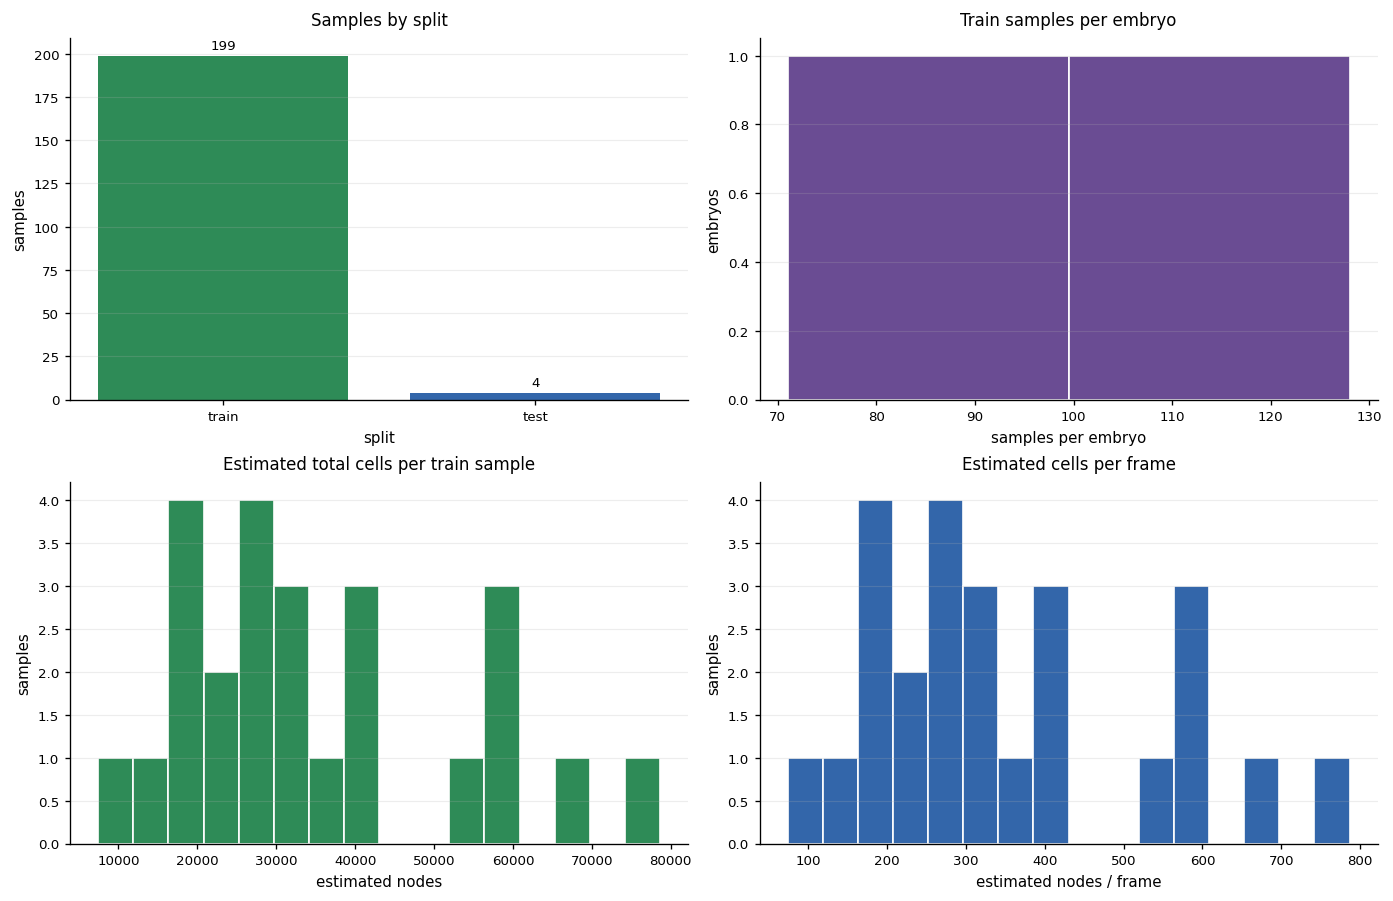

In [7]:
train_names = list_zarr_names(TRAIN_DIR)
test_names = list_zarr_names(TEST_DIR)

train_embryos = set(map(embryo_id, train_names)) if train_names else set()
test_embryos = set(map(embryo_id, test_names)) if test_names else set()

split_summary = pd.DataFrame([
    {'split': 'train', 'n_samples': len(train_names), 'n_embryos': len(train_embryos)},
    {'split': 'test', 'n_samples': len(test_names), 'n_embryos': len(test_embryos)},
])

train_info = scan_split(TRAIN_DIR, EDA_SAMPLE_LIMIT) if RUN_BASIC_EDA else pd.DataFrame()
test_info = scan_split(TEST_DIR, EDA_SAMPLE_LIMIT) if RUN_BASIC_EDA else pd.DataFrame()

if RUN_BASIC_EDA:
    display(split_summary)

    if train_embryos and test_embryos:
        overlap = sorted(train_embryos & test_embryos)
        if overlap:
            print('visible train/test embryo overlap:', overlap[:10], 'count=', len(overlap))
            print('This can occur in the visible example split; it is logged but not treated as a failure.')
        else:
            print('visible train/test embryo overlap: none')

    print('train metric-oriented metadata')
    display(train_info.head())
    print('test metric-oriented metadata')
    display(test_info.head())

    for label, df in [('train', train_info), ('test', test_info)]:
        if len(df):
            print(f'{label} geometry summary')
            display(df.groupby(['T', 'Z', 'Y', 'X']).size().rename('n').reset_index())
            numeric_cols = ['estimated_number_of_nodes', 'estimated_nodes_per_frame']
            existing = [c for c in numeric_cols if c in df.columns and df[c].notna().any()]
            if existing:
                display(df[existing].describe())

    fig, axes = plt.subplots(2, 2, figsize=(11.5, 7.4), constrained_layout=True)
    axes = axes.ravel()

    bars = axes[0].bar(split_summary['split'], split_summary['n_samples'], color=[PLOT_COLORS['green'], PLOT_COLORS['blue']])
    annotate_bars(axes[0], bars)
    style_axis(axes[0], 'Samples by split', 'split', 'samples')

    embryo_counts = pd.Series([embryo_id(n) for n in train_names], name='embryo').value_counts()
    if len(embryo_counts):
        axes[1].hist(embryo_counts.values, bins=min(20, max(1, len(embryo_counts))), color=PLOT_COLORS['purple'], edgecolor='white')
        style_axis(axes[1], 'Train samples per embryo', 'samples per embryo', 'embryos')
    else:
        hide_axis(axes[1])

    if len(train_info) and train_info['estimated_number_of_nodes'].notna().any():
        vals = train_info['estimated_number_of_nodes'].dropna()
        axes[2].hist(vals, bins=min(16, max(4, len(vals))), color=PLOT_COLORS['green'], edgecolor='white')
        style_axis(axes[2], 'Estimated total cells per train sample', 'estimated nodes', 'samples')
    else:
        hide_axis(axes[2], 'No estimated counts')

    if len(train_info) and train_info['estimated_nodes_per_frame'].notna().any():
        vals = train_info['estimated_nodes_per_frame'].dropna()
        axes[3].hist(vals, bins=min(16, max(4, len(vals))), color=PLOT_COLORS['blue'], edgecolor='white')
        style_axis(axes[3], 'Estimated cells per frame', 'estimated nodes / frame', 'samples')
    else:
        hide_axis(axes[3], 'No count density')

    plt.show()
else:
    print(f'RUN_BASIC_EDA=False; found {len(train_names)} train and {len(test_names)} test samples.')


## Optional Ground-Truth Graph EDA

Training labels are sparse, so the graph EDA is not a full census of cells. It is still useful for measuring the geometry of annotated events:

| statistic | modelling decision |
|---|---|
| edge displacement percentiles | choose and sanity-check `MAX_LINK_DIST`. |
| edge time gap $\Delta t$ | decide whether adjacent-frame-only links are enough. |
| division count and daughter distance | tune `DETECT_DIVISIONS`, `DIV_PARENT_DIST`, and `DIV_SISTER_DIST`. |
| labelled-to-estimated ratio | measure annotation sparsity and avoid treating unlabeled cells as background. |

The key motion quantity is

$$
d_{edge}=\lVert (p_{target}-p_{source})\odot s\rVert_2.
$$

If the high percentiles of $d_{edge}$ exceed `MAX_LINK_DIST`, the linker will create false negatives even when detections are correct. If many annotated edges have $\Delta t>1$, skip-frame edge candidates should be tested separately.


In [8]:
def load_geff_raw(geff_path: Path) -> tuple[pd.DataFrame, pd.DataFrame] | tuple[None, None]:
    if zarr is None or geff_path is None or not geff_path.exists():
        return None, None
    try:
        root = zarr.open_group(str(geff_path), mode='r')
        node_ids = np.asarray(root['nodes/ids'][:]).astype(np.int64)
        data = {'node_id': node_ids}
        for key in ('t', 'z', 'y', 'x'):
            data[key] = np.asarray(root[f'nodes/props/{key}/values'][:])
        nodes = pd.DataFrame(data)
        edges_arr = np.asarray(root['edges/ids'][:]).astype(np.int64)
        edges = pd.DataFrame(edges_arr, columns=['source_id', 'target_id']) if len(edges_arr) else pd.DataFrame(columns=['source_id', 'target_id'])
        return nodes, edges
    except Exception:
        return None, None


def geff_stats_for_sample(name: str) -> dict | None:
    geff_path = TRAIN_DIR / f'{name}.geff'
    nodes, edges = load_geff_raw(geff_path)
    if nodes is None:
        return None

    node_pos = nodes.set_index('node_id')[['t', 'z', 'y', 'x']]
    out_degree = edges['source_id'].value_counts() if len(edges) else pd.Series(dtype=int)
    divisions = out_degree[out_degree >= 2]

    displacements = []
    edge_dts = []
    for source_id, target_id in edges[['source_id', 'target_id']].itertuples(index=False):
        if source_id in node_pos.index and target_id in node_pos.index:
            src = node_pos.loc[source_id]
            tgt = node_pos.loc[target_id]
            edge_dts.append(int(tgt['t'] - src['t']))
            dz_y_x = np.array([tgt['z'] - src['z'], tgt['y'] - src['y'], tgt['x'] - src['x']], dtype=np.float64)
            displacements.append(float(np.linalg.norm(dz_y_x * SCALE)))

    sister_distances = []
    for source_id in divisions.index:
        daughters = edges.loc[edges['source_id'] == source_id, 'target_id'].tolist()
        daughters = [d for d in daughters if d in node_pos.index]
        if len(daughters) >= 2:
            a = node_pos.loc[daughters[0]][['z', 'y', 'x']].to_numpy(dtype=np.float64)
            b = node_pos.loc[daughters[1]][['z', 'y', 'x']].to_numpy(dtype=np.float64)
            sister_distances.append(float(np.linalg.norm((a - b) * SCALE)))

    edge_dts = np.asarray(edge_dts, dtype=np.int64)
    est = read_estimated_nodes(geff_path)
    return {
        'name': name,
        'embryo': embryo_id(name),
        'annotated_nodes': len(nodes),
        'annotated_edges': len(edges),
        'timepoints_covered': nodes['t'].nunique(),
        'divisions': int(len(divisions)),
        'division_rate': float(len(divisions) / max(len(nodes), 1)),
        'estimated_number_of_nodes': est,
        'labelled_to_estimated_ratio': float(len(nodes) / est) if np.isfinite(est) and est > 0 else np.nan,
        'edge_dt_min': np.nan if len(edge_dts) == 0 else int(edge_dts.min()),
        'edge_dt_p50': np.nan if len(edge_dts) == 0 else float(np.percentile(edge_dts, 50)),
        'edge_dt_p95': np.nan if len(edge_dts) == 0 else float(np.percentile(edge_dts, 95)),
        'edge_dt_max': np.nan if len(edge_dts) == 0 else int(edge_dts.max()),
        'frac_edge_dt_gt_1': np.nan if len(edge_dts) == 0 else float((edge_dts > 1).mean()),
        'motion_p50_um': np.nan if not displacements else float(np.percentile(displacements, 50)),
        'motion_p95_um': np.nan if not displacements else float(np.percentile(displacements, 95)),
        'motion_p99_um': np.nan if not displacements else float(np.percentile(displacements, 99)),
        'motion_max_um': np.nan if not displacements else float(np.max(displacements)),
        'sister_p50_um': np.nan if not sister_distances else float(np.percentile(sister_distances, 50)),
        'sister_p90_um': np.nan if not sister_distances else float(np.percentile(sister_distances, 90)),
        'sister_p95_um': np.nan if not sister_distances else float(np.percentile(sister_distances, 95)),
    }


In [9]:
if not RUN_GT_EDA:
    print('RUN_GT_EDA=False; GT graph EDA skipped.')
elif not train_names:
    print('No train data found; GT graph EDA skipped.')
else:
    gt_sample_names = select_diverse_samples(train_names, GT_EDA_SAMPLE_LIMIT)
    display(pd.DataFrame({'gt_sample': gt_sample_names, 'embryo': [embryo_id(n) for n in gt_sample_names]}))
    gt_rows = []
    for name in gt_sample_names:
        row = geff_stats_for_sample(name)
        if row is not None:
            gt_rows.append(row)
    gt_info = pd.DataFrame(gt_rows)

    if len(gt_info):
        display(gt_info)
        numeric_cols = [c for c in gt_info.columns if c not in {'name', 'embryo'}]
        display(gt_info[numeric_cols].describe())

        fig, axes = plt.subplots(2, 3, figsize=(12.6, 7.6), constrained_layout=True)
        axes = axes.ravel()

        gt_info['annotated_nodes'].dropna().plot(kind='hist', bins=12, ax=axes[0], color=PLOT_COLORS['green'], edgecolor='white')
        style_axis(axes[0], 'Annotated nodes per sample', 'nodes', 'samples')

        motion_vals = gt_info['motion_p99_um'].dropna()
        if len(motion_vals):
            axes[1].hist(motion_vals, bins=12, color=PLOT_COLORS['blue'], edgecolor='white')
            axes[1].axvline(MAX_LINK_DIST, color=PLOT_COLORS['red'], linestyle='--', linewidth=1.4, label='MAX_LINK_DIST')
            axes[1].legend(frameon=False)
            style_axis(axes[1], 'GT edge displacement p99', 'um', 'samples')
        else:
            hide_axis(axes[1])

        dt_vals = gt_info['edge_dt_max'].dropna() if 'edge_dt_max' in gt_info else pd.Series(dtype=float)
        if len(dt_vals):
            bins = np.arange(float(dt_vals.min()) - 0.5, float(dt_vals.max()) + 1.5, 1.0)
            axes[2].hist(dt_vals, bins=bins, color=PLOT_COLORS['orange'], edgecolor='white')
            style_axis(axes[2], 'Maximum GT edge time gap', 'max delta t', 'samples')
        else:
            hide_axis(axes[2], 'No edge time gaps')

        sister_vals = gt_info['sister_p90_um'].dropna() if 'sister_p90_um' in gt_info else pd.Series(dtype=float)
        if len(sister_vals):
            axes[3].hist(sister_vals, bins=12, color=PLOT_COLORS['purple'], edgecolor='white')
            axes[3].axvline(DIV_SISTER_DIST, color=PLOT_COLORS['red'], linestyle='--', linewidth=1.4, label='DIV_SISTER_DIST')
            axes[3].legend(frameon=False)
            style_axis(axes[3], 'Daughter separation p90', 'um', 'samples')
        else:
            hide_axis(axes[3], 'No divisions')

        gt_info['division_rate'].dropna().plot(kind='hist', bins=12, ax=axes[4], color=PLOT_COLORS['gray'], edgecolor='white')
        style_axis(axes[4], 'Division rate in sparse labels', 'divisions / node', 'samples')

        frac_vals = gt_info['frac_edge_dt_gt_1'].dropna() if 'frac_edge_dt_gt_1' in gt_info else pd.Series(dtype=float)
        if len(frac_vals):
            axes[5].hist(frac_vals, bins=np.linspace(0, 1, 11), color=PLOT_COLORS['red'], edgecolor='white')
            style_axis(axes[5], 'Fraction of GT edges with delta t > 1', 'fraction', 'samples')
        else:
            hide_axis(axes[5], 'No edge time gaps')
        plt.show()
    else:
        print('GT graph EDA unavailable. Install zarr or run with train labels mounted.')


,gt_sample,embryo
0,44b6_0113de3b,44b6
1,6bba_05b6850b,6bba
2,44b6_0b24845f,44b6
3,44b6_0c582fdc,44b6
4,44b6_0db75fae,44b6
5,44b6_12dfb391,44b6
6,44b6_144b256d,44b6
7,44b6_1574802b,44b6


GT graph EDA unavailable. Install zarr or run with train labels mounted.


## Classical Baseline

The baseline follows the voxel geometry. It keeps full Z resolution and performs only X/Y average pooling. With `XY_DS=4`, the working voxel size becomes approximately

$$
(1.625,\ 4\times0.40625,\ 4\times0.40625)=(1.625,1.625,1.625)\ \mu m.
$$

Detection is peak-based rather than component-based. After smoothing the near-isotropic working grid, the threshold is

$$
\theta=\max\left(\theta_{Otsu},\ P_{50}+\alpha(P_{99.8}-P_{50})\right),
$$

where $\alpha=$ `THRESH_REL`. Each local maximum above $\theta$ becomes one centroid candidate, and `MIN_PEAK_DIST` controls the minimum separation between detections on the working grid.

The working-grid peak is then mapped back to original voxel coordinates and optionally refined in the original volume. For a local window $W$ around a candidate, define

$$
w(\mathbf r)=\max(I(\mathbf r)-P_{20}(I_W),0).
$$

The refined centroid is the intensity-weighted coordinate

$$
\widehat{\mathbf r}=\frac{\sum_{\mathbf r\in W}\mathbf r\,w(\mathbf r)}{\sum_{\mathbf r\in W}w(\mathbf r)}.
$$

Duplicate candidates are suppressed in physical space, not voxel space:

$$
d_{ij}=\lVert (\widehat{\mathbf r}_i-\widehat{\mathbf r}_j)\odot s\rVert_2.
$$

Physical NMS keeps the highest-scoring candidate inside radius `NMS_RADIUS_UM`. A weak-border filter removes only low-scoring boundary peaks. If $\beta$ is `BORDER_KEEP_QUANTILE`, the score floor is

$$
q_{border}=Q_{\beta}(\{s_i\}).
$$

The frame-count stabilizer prevents threshold failures from creating a sudden node explosion. Let $a$ be `MAX_FRAME_COUNT_MULT` and $b$ be `MAX_FRAME_COUNT_ADD`. The cap is

$$
\widehat N_t \le a\,\widehat N_{t-1}+b.
$$

Only the highest-scoring candidates up to that cap are kept.

Temporal linking is a one-to-one assignment between consecutive frames, with costs measured in microns and gated by `MAX_LINK_DIST`. The optional division pass adds a second outgoing edge only when an unmatched detection is close to a parent that already has one child and both daughters continue into the next frame when `DIV_REQUIRE_CONTINUED=True`. This keeps division prediction conservative because a false division creates both an edge false positive and a division false positive.


In [10]:
def load_volume(zarr_path: Path, t: int, shape: tuple[int, ...], dtype: np.dtype) -> np.ndarray:
    chunk = zarr_path / '0' / 'c' / str(t) / '0' / '0' / '0'
    if blosc2 is not None and chunk.exists():
        try:
            raw = blosc2.decompress(chunk.read_bytes())
            return np.frombuffer(raw, dtype=dtype).reshape(shape[1:])
        except Exception:
            pass
    if zarr is not None:
        arr = zarr.open_array(str(zarr_path / '0'), mode='r')
        return np.asarray(arr[t], dtype=dtype)
    raise ImportError('Either blosc2 or zarr is required to read the Zarr volumes.')


def block_mean_xy(vol: np.ndarray, factor: int) -> np.ndarray:
    z, y, x = vol.shape
    y2, x2 = (y // factor) * factor, (x // factor) * factor
    arr = vol[:, :y2, :x2].astype(np.float32, copy=False)
    return arr.reshape(z, y2 // factor, factor, x2 // factor, factor).mean(axis=(2, 4))


def normalize_working_grid(ds: np.ndarray, cfg: CONFIG = CFG) -> np.ndarray:
    x = ds.astype(np.float32, copy=False)
    lo = float(np.percentile(x, cfg.NORM_LOW_PERCENTILE))
    hi = float(np.percentile(x, cfg.NORM_HIGH_PERCENTILE))
    x = np.clip((x - lo) / max(hi - lo, 1e-6), 0.0, 1.0)
    if cfg.BG_SUBTRACT_SIGMA > 0:
        bg = gaussian_filter(x, sigma=cfg.BG_SUBTRACT_SIGMA)
        x = np.clip(x - bg, 0.0, None)
    return x.astype(np.float32, copy=False)


def threshold_components(smoothed: np.ndarray, cfg: CONFIG = CFG, thresh_rel: float | None = None) -> dict:
    alpha = cfg.THRESH_REL if thresh_rel is None else float(thresh_rel)
    bg = float(np.percentile(smoothed, 50.0))
    hi = float(np.percentile(smoothed, cfg.THRESH_HI_PERCENTILE))
    rel = bg + alpha * (hi - bg)
    otsu = np.nan
    if threshold_otsu is not None:
        try:
            otsu = float(threshold_otsu(smoothed))
        except Exception:
            otsu = np.nan
    fallback = float(np.percentile(smoothed, cfg.THRESH_PERCENTILE))
    driver = 'relative'
    if np.isfinite(otsu):
        threshold = max(otsu, rel)
        driver = 'otsu' if otsu >= rel else 'relative'
    else:
        threshold = max(fallback, rel)
        driver = 'percentile' if fallback >= rel else 'relative'
    if cfg.USE_PERCENTILE_FLOOR and fallback > threshold:
        threshold = fallback
        driver = 'percentile'
    return {
        'threshold_final': float(threshold),
        'threshold_rel': float(rel),
        'threshold_otsu': float(otsu) if np.isfinite(otsu) else np.nan,
        'threshold_percentile': float(fallback),
        'threshold_driver': driver,
    }


def robust_threshold(smoothed: np.ndarray, cfg: CONFIG = CFG) -> float:
    return threshold_components(smoothed, cfg)['threshold_final']


def _fallback_peak_local_max(smoothed: np.ndarray, threshold: float, min_distance: int) -> np.ndarray:
    size = 2 * min_distance + 1
    local_max = maximum_filter(smoothed, size=size, mode='nearest')
    candidates = np.argwhere((smoothed == local_max) & (smoothed >= threshold))
    if len(candidates) == 0:
        return np.empty((0, 3), dtype=np.int64)
    intensities = smoothed[candidates[:, 0], candidates[:, 1], candidates[:, 2]]
    order = np.argsort(-intensities)
    selected = []
    min_sq = float(min_distance ** 2)
    for idx in order:
        point = candidates[idx]
        if all(float(np.sum((point - prev) ** 2)) >= min_sq for prev in selected):
            selected.append(point)
    return np.asarray(selected, dtype=np.int64) if selected else np.empty((0, 3), dtype=np.int64)


def _find_peaks(smoothed: np.ndarray, threshold: float, min_distance: int) -> np.ndarray:
    if peak_local_max is not None:
        return peak_local_max(smoothed, min_distance=min_distance, threshold_abs=threshold, exclude_border=False)
    return _fallback_peak_local_max(smoothed, threshold, min_distance)


def _rescue_topk_peaks(smoothed: np.ndarray, topk: int) -> np.ndarray:
    if topk <= 0 or smoothed.size == 0:
        return np.empty((0, 3), dtype=np.int64)
    k = min(int(topk), smoothed.size)
    flat = np.argpartition(smoothed.ravel(), -k)[-k:]
    peaks = np.array(np.unravel_index(flat, smoothed.shape)).T
    vals = smoothed[peaks[:, 0], peaks[:, 1], peaks[:, 2]]
    return peaks[np.argsort(-vals)].astype(np.int64)


def _working_to_original(peaks: np.ndarray, cfg: CONFIG = CFG) -> np.ndarray:
    if peaks.size == 0:
        return np.empty((0, 3), dtype=np.float64)
    out = peaks.astype(np.float64)
    out[:, 1] = out[:, 1] * cfg.XY_DS + (cfg.XY_DS - 1) / 2.0
    out[:, 2] = out[:, 2] * cfg.XY_DS + (cfg.XY_DS - 1) / 2.0
    return out


def refine_centroid(vol: np.ndarray, coord: np.ndarray, base_score: float, cfg: CONFIG = CFG) -> tuple[np.ndarray, float]:
    zc, yc, xc = [int(round(v)) for v in coord]
    z0 = max(0, zc - cfg.REFINE_RADIUS_Z)
    z1 = min(vol.shape[0], zc + cfg.REFINE_RADIUS_Z + 1)
    y0 = max(0, yc - cfg.REFINE_RADIUS_YX)
    y1 = min(vol.shape[1], yc + cfg.REFINE_RADIUS_YX + 1)
    x0 = max(0, xc - cfg.REFINE_RADIUS_YX)
    x1 = min(vol.shape[2], xc + cfg.REFINE_RADIUS_YX + 1)
    patch = vol[z0:z1, y0:y1, x0:x1].astype(np.float32, copy=False)
    if patch.size == 0:
        clipped = np.array([
            np.clip(coord[0], 0, vol.shape[0] - 1),
            np.clip(coord[1], 0, vol.shape[1] - 1),
            np.clip(coord[2], 0, vol.shape[2] - 1),
        ], dtype=np.float64)
        return clipped, float(base_score)
    bg = float(np.percentile(patch, cfg.REFINE_BG_PERCENTILE))
    weights = np.clip(patch - bg, 0.0, None)
    total = float(weights.sum())
    local_max = float(weights.max()) if weights.size else 0.0
    if total <= 1e-6:
        loc = np.unravel_index(int(np.argmax(patch)), patch.shape)
        refined = np.array([z0 + loc[0], y0 + loc[1], x0 + loc[2]], dtype=np.float64)
    else:
        zz, yy, xx = np.indices(patch.shape, dtype=np.float32)
        refined = np.array([
            z0 + float((zz * weights).sum() / total),
            y0 + float((yy * weights).sum() / total),
            x0 + float((xx * weights).sum() / total),
        ], dtype=np.float64)
    refined[0] = np.clip(refined[0], 0, vol.shape[0] - 1)
    refined[1] = np.clip(refined[1], 0, vol.shape[1] - 1)
    refined[2] = np.clip(refined[2], 0, vol.shape[2] - 1)
    return refined, float(max(float(base_score), local_max))


def physical_nms(coords_vox: np.ndarray, scores: np.ndarray, radius_um: float, scale: np.ndarray = SCALE) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    if len(coords_vox) == 0:
        return coords_vox, scores, np.array([], dtype=np.int64)
    pts = coords_vox.astype(np.float64, copy=False) * scale[None, :]
    order = np.argsort(-scores)
    tree = cKDTree(pts)
    suppressed = np.zeros(len(coords_vox), dtype=bool)
    keep = []
    for idx in order:
        if suppressed[idx]:
            continue
        keep.append(int(idx))
        close = tree.query_ball_point(pts[idx], r=float(radius_um))
        suppressed[close] = True
    keep = np.asarray(keep, dtype=np.int64)
    return coords_vox[keep], scores[keep], keep


def apply_border_filter(coords: np.ndarray, scores: np.ndarray, shape_zyx: tuple[int, int, int], cfg: CONFIG = CFG) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    if len(coords) == 0 or not cfg.USE_BORDER_FILTER:
        return coords, scores, np.arange(len(coords), dtype=np.int64)
    z, y, x = coords[:, 0], coords[:, 1], coords[:, 2]
    Z, Y, X = shape_zyx
    border = (
        (z <= cfg.BORDER_Z) | (z >= Z - 1 - cfg.BORDER_Z) |
        (y <= cfg.BORDER_YX) | (y >= Y - 1 - cfg.BORDER_YX) |
        (x <= cfg.BORDER_YX) | (x >= X - 1 - cfg.BORDER_YX)
    )
    floor = float(np.quantile(scores, cfg.BORDER_KEEP_QUANTILE)) if len(scores) else np.inf
    keep_mask = (~border) | (scores >= floor)
    if not np.any(keep_mask):
        keep_mask[int(np.argmax(scores))] = True
    keep_idx = np.flatnonzero(keep_mask).astype(np.int64)
    return coords[keep_idx], scores[keep_idx], keep_idx


def _apply_topk_and_count_caps(coords: np.ndarray, scores: np.ndarray, cfg: CONFIG = CFG, prev_count: int | None = None) -> tuple[np.ndarray, np.ndarray]:
    if len(coords) == 0:
        return coords, scores
    keep_n = len(coords)
    if cfg.USE_TOPK_COUNT_CONTROL and cfg.TOPK_PER_FRAME is not None:
        keep_n = min(keep_n, int(np.clip(round(cfg.TOPK_PER_FRAME * cfg.TOPK_MULTIPLIER), cfg.MIN_NODES_PER_FRAME, cfg.MAX_NODES_PER_FRAME)))
    if cfg.USE_COUNT_STABILIZER and prev_count is not None and prev_count >= 8:
        cap = int(prev_count * cfg.MAX_FRAME_COUNT_MULT + cfg.MAX_FRAME_COUNT_ADD)
        keep_n = min(keep_n, max(cfg.MIN_NODES_PER_FRAME, cap))
    keep_n = min(keep_n, cfg.MAX_NODES_PER_FRAME)
    if keep_n < len(coords):
        order = np.argsort(-scores)[:keep_n]
        coords = coords[order]
        scores = scores[order]
    return coords, scores


def _single_mode_candidates(vol: np.ndarray, cfg: CONFIG = CFG) -> tuple[np.ndarray, np.ndarray, pd.DataFrame]:
    ds = block_mean_xy(vol, cfg.XY_DS)
    sm = gaussian_filter(ds, sigma=cfg.SMOOTH_SIGMA)
    comps = threshold_components(sm, cfg)
    peaks = _find_peaks(sm, comps['threshold_final'], cfg.MIN_PEAK_DIST)
    if peaks.size == 0 and cfg.EMPTY_FRAME_RESCUE_TOPK > 0:
        peaks = _rescue_topk_peaks(sm, cfg.EMPTY_FRAME_RESCUE_TOPK)
    if peaks.size == 0:
        return np.empty((0, 3), dtype=np.float64), np.empty((0,), dtype=np.float64), pd.DataFrame()
    coords = _working_to_original(peaks, cfg)
    peak_values = sm[peaks[:, 0], peaks[:, 1], peaks[:, 2]].astype(np.float64)
    med = float(np.median(sm))
    denom = max(float(np.percentile(sm, cfg.THRESH_HI_PERCENTILE)) - med, 1e-6)
    rel_contrast = (peak_values - med) / denom
    keep = rel_contrast >= cfg.MIN_REL_CONTRAST
    if not np.any(keep):
        keep[int(np.argmax(peak_values))] = True
    meta = pd.DataFrame({
        'z': coords[:, 0], 'y': coords[:, 1], 'x': coords[:, 2],
        'score': peak_values, 'peak_value': peak_values,
        'local_contrast': peak_values - med,
        'rel_contrast': rel_contrast,
        'sigma': cfg.SMOOTH_SIGMA,
        'threshold_rel': cfg.THRESH_REL,
        'threshold_driver': comps['threshold_driver'],
    })
    return coords[keep], peak_values[keep], meta.loc[keep].reset_index(drop=True)


def detect_candidates_multiscale(vol: np.ndarray, cfg: CONFIG = CFG) -> pd.DataFrame:
    ds = block_mean_xy(vol, cfg.XY_DS)
    norm = normalize_working_grid(ds, cfg)
    rows = []
    for sigma in cfg.SMOOTH_SIGMAS:
        sm = gaussian_filter(norm, sigma=float(sigma))
        local_bg = gaussian_filter(sm, sigma=max(1.5, float(sigma) * 3.0))
        med = float(np.median(sm))
        hi = float(np.percentile(sm, cfg.THRESH_HI_PERCENTILE))
        denom = max(hi - med, 1e-6)
        for rel in cfg.THRESH_REL_GRID:
            comps = threshold_components(sm, cfg, thresh_rel=float(rel))
            peaks = _find_peaks(sm, comps['threshold_final'], cfg.CANDIDATE_MIN_PEAK_DIST)
            if peaks.size == 0:
                continue
            vals = sm[peaks[:, 0], peaks[:, 1], peaks[:, 2]]
            bg_vals = local_bg[peaks[:, 0], peaks[:, 1], peaks[:, 2]]
            contrast = vals - bg_vals
            rel_contrast = (vals - med) / denom
            orig = _working_to_original(peaks, cfg)
            score = contrast + 0.25 * vals
            for point, s, val, con, rc in zip(orig, score, vals, contrast, rel_contrast):
                if rc < cfg.MIN_REL_CONTRAST:
                    continue
                rows.append({
                    'z': float(point[0]), 'y': float(point[1]), 'x': float(point[2]),
                    'score': float(s), 'sigma': float(sigma), 'threshold_rel': float(rel),
                    'peak_value': float(val), 'local_contrast': float(con), 'rel_contrast': float(rc),
                    'threshold_driver': comps['threshold_driver'],
                })
    if not rows:
        return pd.DataFrame(columns=['z', 'y', 'x', 'score', 'sigma', 'threshold_rel', 'peak_value', 'local_contrast', 'rel_contrast', 'threshold_driver'])
    return pd.DataFrame(rows).sort_values('score', ascending=False).reset_index(drop=True)


def detect_centroids_with_scores(vol: np.ndarray, cfg: CONFIG = CFG, prev_count: int | None = None) -> tuple[np.ndarray, np.ndarray]:
    if cfg.DETECTION_MODE == 'single':
        coords, scores, _ = _single_mode_candidates(vol, cfg)
    elif cfg.DETECTION_MODE == 'multiscale':
        cands = detect_candidates_multiscale(vol, cfg)
        if len(cands) == 0 and cfg.EMPTY_FRAME_RESCUE_TOPK > 0:
            ds = block_mean_xy(vol, cfg.XY_DS)
            sm = gaussian_filter(normalize_working_grid(ds, cfg), sigma=cfg.SMOOTH_SIGMA)
            peaks = _rescue_topk_peaks(sm, cfg.EMPTY_FRAME_RESCUE_TOPK)
            coords = _working_to_original(peaks, cfg)
            scores = sm[peaks[:, 0], peaks[:, 1], peaks[:, 2]].astype(np.float64) if len(peaks) else np.empty((0,), dtype=np.float64)
        elif len(cands) == 0:
            coords = np.empty((0, 3), dtype=np.float64)
            scores = np.empty((0,), dtype=np.float64)
        else:
            coords = cands[['z', 'y', 'x']].to_numpy(dtype=np.float64)
            scores = cands['score'].to_numpy(dtype=np.float64)
    else:
        raise ValueError(f'Unknown DETECTION_MODE: {cfg.DETECTION_MODE}')

    if len(coords) == 0:
        return coords, scores

    if cfg.USE_CENTROID_REFINEMENT:
        refined = []
        refined_scores = []
        for coord, score in zip(coords, scores):
            point, new_score = refine_centroid(vol, coord, float(score), cfg)
            refined.append(point)
            refined_scores.append(new_score)
        coords = np.asarray(refined, dtype=np.float64)
        scores = np.asarray(refined_scores, dtype=np.float64)

    if cfg.USE_PHYSICAL_NMS and len(coords):
        nms_radius = cfg.FINAL_NMS_RADIUS_UM if cfg.DETECTION_MODE == 'multiscale' else cfg.NMS_RADIUS_UM
        coords, scores, _ = physical_nms(coords, scores, nms_radius, np.array(cfg.SCALE, dtype=np.float64))

    coords, scores, _ = apply_border_filter(coords, scores, vol.shape, cfg)

    coords, scores = _apply_topk_and_count_caps(coords, scores, cfg, prev_count=prev_count)
    return coords.astype(np.float64, copy=False), scores.astype(np.float64, copy=False)


def physical_nms_candidates(cands: pd.DataFrame, cfg: CONFIG = CFG) -> pd.DataFrame:
    if len(cands) == 0:
        return cands
    coords = cands[['z', 'y', 'x']].to_numpy(dtype=np.float64)
    scores = cands['score'].to_numpy(dtype=np.float64)
    _, _, keep = physical_nms(coords, scores, cfg.FINAL_NMS_RADIUS_UM, np.array(cfg.SCALE, dtype=np.float64))
    out = cands.iloc[keep].copy().reset_index(drop=True)
    if cfg.USE_TOPK_COUNT_CONTROL and cfg.TOPK_PER_FRAME is not None:
        keep_n = int(np.clip(round(cfg.TOPK_PER_FRAME * cfg.TOPK_MULTIPLIER), cfg.MIN_NODES_PER_FRAME, cfg.MAX_NODES_PER_FRAME))
        out = out.head(keep_n).copy().reset_index(drop=True)
    return out


def detect_centroids(vol: np.ndarray, cfg: CONFIG = CFG) -> np.ndarray:
    coords, _ = detect_centroids_with_scores(vol, cfg, prev_count=None)
    return coords


def _effective_max_link(cfg: CONFIG = CFG) -> float:
    return cfg.TIGHT_MAX_LINK_DIST if cfg.TIGHT_LINK_PROFILE else cfg.MAX_LINK_DIST


def _effective_div_parent(cfg: CONFIG = CFG) -> float:
    return cfg.TIGHT_DIV_PARENT_DIST if cfg.TIGHT_LINK_PROFILE else cfg.DIV_PARENT_DIST


def _effective_div_sister(cfg: CONFIG = CFG) -> float:
    return cfg.TIGHT_DIV_SISTER_DIST if cfg.TIGHT_LINK_PROFILE else cfg.DIV_SISTER_DIST


def _has_next_detection(point_phys: np.ndarray, next_xyz: np.ndarray | None, cfg: CONFIG = CFG) -> bool:
    if next_xyz is None or len(next_xyz) == 0:
        return False
    next_phys = next_xyz * np.array(cfg.SCALE, dtype=np.float64)
    d = np.sqrt(((next_phys - point_phys[None, :]) ** 2).sum(axis=1))
    return bool(np.any(d <= _effective_max_link(cfg)))


def link_with_divisions(
    prev_ids,
    prev_xyz,
    curr_ids,
    curr_xyz,
    next_xyz: np.ndarray | None = None,
    prev_velocity_phys: np.ndarray | None = None,
    cfg: CONFIG = CFG,
) -> list[tuple[int, int]]:
    edges = []
    if len(prev_ids) == 0 or len(curr_ids) == 0:
        return edges

    scale = np.array(cfg.SCALE, dtype=np.float64)
    prev_phys = prev_xyz * scale
    curr_phys = curr_xyz * scale
    delta = curr_phys[None, :, :] - prev_phys[:, None, :]
    dist = np.sqrt((delta ** 2).sum(axis=2))

    max_link = _effective_max_link(cfg)
    parent_dist = _effective_div_parent(cfg)
    sister_dist_limit = _effective_div_sister(cfg)

    cost_base = dist
    if cfg.USE_MOTION_COST and prev_velocity_phys is not None and len(prev_velocity_phys) == len(prev_ids):
        motion_resid = delta - prev_velocity_phys[:, None, :]
        motion_cost = np.sqrt((motion_resid ** 2).sum(axis=2))
        cost_base = dist + cfg.MOTION_LAMBDA * motion_cost

    big = 1e6
    cost = np.where(dist <= max_link, cost_base, big)
    row_ind, col_ind = linear_sum_assignment(cost)

    parent_children = {}
    matched_curr = set()
    for r, c in zip(row_ind, col_ind):
        if cost[r, c] < big:
            edges.append((prev_ids[r], curr_ids[c]))
            parent_children.setdefault(r, []).append(c)
            matched_curr.add(c)

    allow_division = cfg.DETECT_DIVISIONS
    if cfg.USE_DIV_COUNT_GAIN_GATE and len(curr_ids) - len(prev_ids) < cfg.DIV_MIN_COUNT_GAIN:
        allow_division = False

    if allow_division:
        for c in range(len(curr_ids)):
            if c in matched_curr:
                continue
            best_parent, best_dist = None, np.inf
            for p in range(len(prev_ids)):
                if dist[p, c] > parent_dist or len(parent_children.get(p, [])) != 1:
                    continue
                sister = parent_children[p][0]
                sister_dist = float(np.sqrt(((curr_phys[c] - curr_phys[sister]) ** 2).sum()))
                if sister_dist > sister_dist_limit:
                    continue
                if cfg.DIV_USE_MIDPOINT:
                    midpoint = 0.5 * (curr_phys[c] + curr_phys[sister])
                    midpoint_dist = float(np.sqrt(((prev_phys[p] - midpoint) ** 2).sum()))
                    if midpoint_dist > cfg.DIV_MIDPOINT_DIST:
                        continue
                if cfg.DIV_REQUIRE_CONTINUED:
                    if next_xyz is None:
                        continue
                    candidate_continues = _has_next_detection(curr_phys[c], next_xyz, cfg)
                    sister_continues = _has_next_detection(curr_phys[sister], next_xyz, cfg)
                    if not (candidate_continues and sister_continues):
                        continue
                if dist[p, c] < best_dist:
                    best_parent, best_dist = p, dist[p, c]
            if best_parent is not None:
                edges.append((prev_ids[best_parent], curr_ids[c]))
                parent_children[best_parent].append(c)
                matched_curr.add(c)
    return edges


## Visual EDA: Detection Geometry and Link Preview

This section decompresses only one or two timepoints from one sample. Each plot corresponds to a specific possible metric failure:

| view | failure mode exposed |
|---|---|
| XY maximum projection + centers | missed or duplicated cells in the image plane. |
| XZ/YZ projections | Z-depth bias after preserving axial resolution. |
| middle Z slice | whether projected centers correspond to visible local structures. |
| smoothed working grid | whether XY pooling preserves separable peaks. |
| intensity histogram | whether the final threshold is too conservative or too permissive. |
| link arrows and displacement histogram | whether `MAX_LINK_DIST` is compatible with observed motion. |

`RUN_VISUAL_EDA` is left on by default because this is the most useful human-facing diagnostic. Set it to `False` only for a strict submission-only rerun.


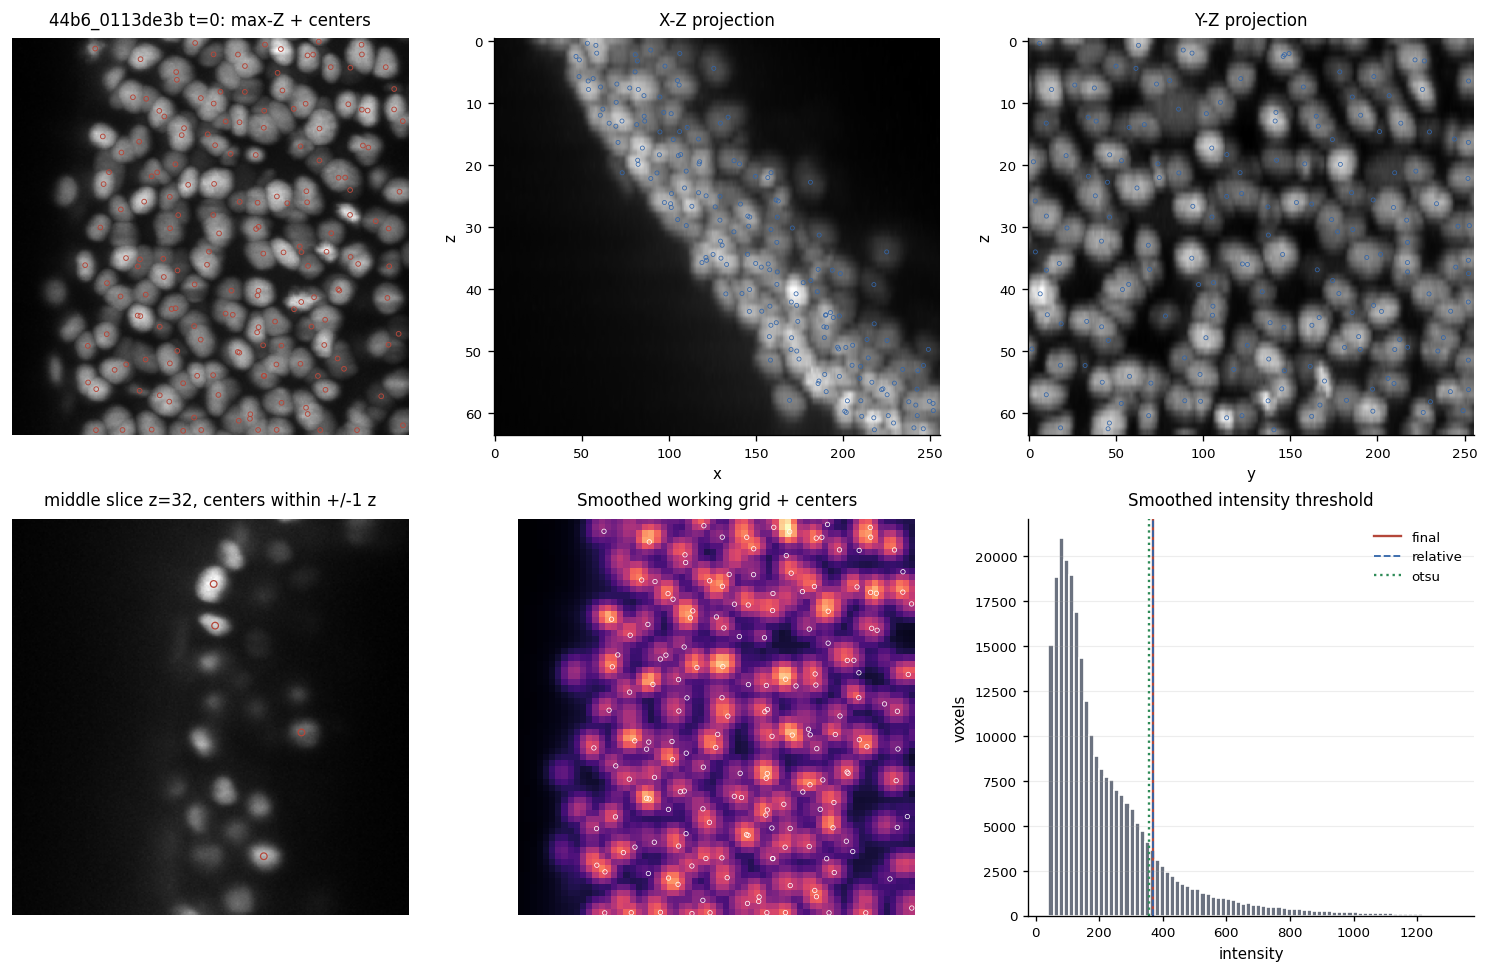

,item,value
0,shape,"(100, 64, 256, 256)"
1,detections,179
2,detections_per_frame_estimate,179
3,detections_per_z_slice,2.797
4,threshold_final,368.142
5,threshold_relative,368.142
6,threshold_otsu,355.598
7,threshold_driver,relative


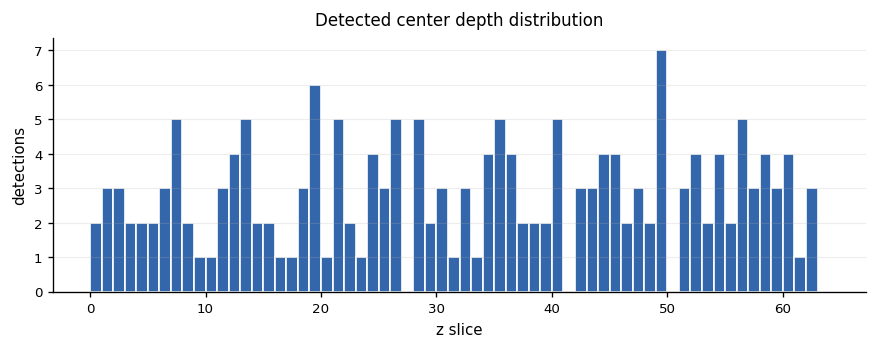

,z,y,x
0,57.977303,137.222224,202.449286
1,60.713343,113.436641,217.631851
2,40.713768,6.405515,173.014906
3,47.798715,101.530094,170.413874
4,34.960169,93.423605,129.900998
5,51.230967,137.606586,174.697696
6,17.197146,104.880773,84.767828
7,54.781422,169.610268,186.121829
8,61.550058,46.102440,228.968065
9,54.028657,57.693910,197.892321


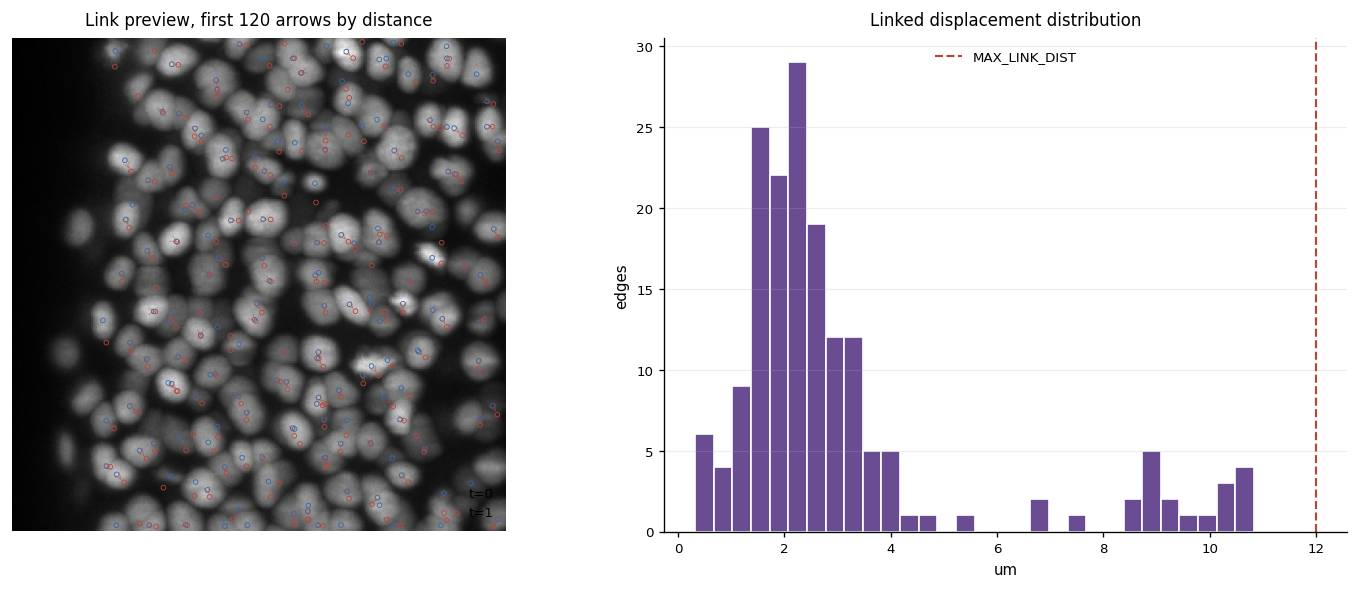

,dataset,frame_t,detections_t,detections_t_plus_1,links,median_link_um,p95_link_um,max_link_um
0,44b6_0113de3b,0,179,180,172,2.290254,9.279409,10.831402


In [11]:
def detection_diagnostics(vol: np.ndarray, cfg: CONFIG = CFG) -> dict:
    ds = block_mean_xy(vol, cfg.XY_DS)
    sm = gaussian_filter(ds, sigma=cfg.SMOOTH_SIGMA)
    comps = threshold_components(sm, cfg)
    bg = float(np.percentile(sm, 50.0))
    hi = float(np.percentile(sm, cfg.THRESH_HI_PERCENTILE))
    return {
        'downsampled': ds,
        'smoothed': sm,
        'bg_p50': bg,
        'hi_percentile': hi,
        'rel_threshold': comps['threshold_rel'],
        'otsu_threshold': comps['threshold_otsu'],
        'percentile_floor': comps['threshold_percentile'],
        'final_threshold': comps['threshold_final'],
        'threshold_driver': comps['threshold_driver'],
    }


def _centers_on_slice(cents: np.ndarray, z: int, window: int = 1) -> np.ndarray:
    if len(cents) == 0:
        return cents
    return cents[np.abs(cents[:, 0] - z) <= window]


def _draw_limited_arrows(ax, prev_xyz: np.ndarray, curr_xyz: np.ndarray, edges: list[tuple[int, int]], max_arrows: int = 120) -> None:
    if not edges:
        return
    edge_rows = []
    for source_id, target_id in edges:
        src_idx = source_id - 1
        tgt_idx = target_id - 1
        if 0 <= src_idx < len(prev_xyz) and 0 <= tgt_idx < len(curr_xyz):
            dist_um = float(np.linalg.norm((curr_xyz[tgt_idx] - prev_xyz[src_idx]) * SCALE))
            edge_rows.append((dist_um, src_idx, tgt_idx))
    edge_rows = sorted(edge_rows, key=lambda row: row[0])[:max_arrows]
    for _, src_idx, tgt_idx in edge_rows:
        y0, x0 = prev_xyz[src_idx, 1], prev_xyz[src_idx, 2]
        y1, x1 = curr_xyz[tgt_idx, 1], curr_xyz[tgt_idx, 2]
        ax.annotate('', xy=(x1, y1), xytext=(x0, y0), arrowprops={'arrowstyle': '->', 'color': PLOT_COLORS['red'], 'lw': 0.45, 'alpha': 0.55})


def show_detection_geometry(name: str, t: int = 0) -> tuple[np.ndarray, np.ndarray, dict, tuple[int, ...], np.dtype]:
    zarr_path = TEST_DIR / f'{name}.zarr'
    shape, dtype = read_zarr_meta(zarr_path)
    vol = load_volume(zarr_path, t, shape, dtype)
    cents = detect_centroids(vol)
    diag = detection_diagnostics(vol)

    mip_xy = vol.max(axis=0)
    mip_xz = vol.max(axis=1)
    mip_yz = vol.max(axis=2)
    mid_z = shape[1] // 2
    slice_cents = _centers_on_slice(cents, mid_z, window=1)
    short_name = short_label(name, 28)

    fig, axes = plt.subplots(2, 3, figsize=(12.5, 8.0), constrained_layout=True)
    axes = axes.ravel()

    axes[0].imshow(mip_xy, cmap='gray')
    if len(cents):
        axes[0].scatter(cents[:, 2], cents[:, 1], s=8, facecolors='none', edgecolors=PLOT_COLORS['red'], linewidths=0.55)
    axes[0].set_title(f'{short_name} t={t}: max-Z + centers', pad=8)
    axes[0].axis('off')

    axes[1].imshow(mip_xz, cmap='gray', aspect='auto')
    if len(cents):
        axes[1].scatter(cents[:, 2], cents[:, 0], s=6, facecolors='none', edgecolors=PLOT_COLORS['blue'], linewidths=0.45)
    axes[1].set_title('X-Z projection', pad=8)
    axes[1].set_xlabel('x')
    axes[1].set_ylabel('z')

    axes[2].imshow(mip_yz, cmap='gray', aspect='auto')
    if len(cents):
        axes[2].scatter(cents[:, 1], cents[:, 0], s=6, facecolors='none', edgecolors=PLOT_COLORS['blue'], linewidths=0.45)
    axes[2].set_title('Y-Z projection', pad=8)
    axes[2].set_xlabel('y')
    axes[2].set_ylabel('z')

    axes[3].imshow(vol[mid_z], cmap='gray')
    if len(slice_cents):
        axes[3].scatter(slice_cents[:, 2], slice_cents[:, 1], s=16, facecolors='none', edgecolors=PLOT_COLORS['red'], linewidths=0.75)
    axes[3].set_title(f'middle slice z={mid_z}, centers within +/-1 z', pad=8)
    axes[3].axis('off')

    sm_mip = diag['smoothed'].max(axis=0)
    axes[4].imshow(sm_mip, cmap='magma')
    if len(cents):
        axes[4].scatter(cents[:, 2] / CFG.XY_DS, cents[:, 1] / CFG.XY_DS, s=7, facecolors='none', edgecolors='white', linewidths=0.45)
    axes[4].set_title('Smoothed working grid + centers', pad=8)
    axes[4].axis('off')

    sm = diag['smoothed'].ravel()
    lo, hi = np.percentile(sm, [1, 99.9])
    axes[5].hist(sm[(sm >= lo) & (sm <= hi)], bins=80, color=PLOT_COLORS['gray'], edgecolor='white')
    axes[5].axvline(diag['final_threshold'], color=PLOT_COLORS['red'], linewidth=1.4, label='final')
    axes[5].axvline(diag['rel_threshold'], color=PLOT_COLORS['blue'], linestyle='--', linewidth=1.1, label='relative')
    if np.isfinite(diag['otsu_threshold']):
        axes[5].axvline(diag['otsu_threshold'], color=PLOT_COLORS['green'], linestyle=':', linewidth=1.4, label='otsu')
    axes[5].legend(frameon=False)
    style_axis(axes[5], 'Smoothed intensity threshold', 'intensity', 'voxels')

    plt.show()

    summary = pd.DataFrame([
        {'item': 'shape', 'value': str(shape)},
        {'item': 'detections', 'value': len(cents)},
        {'item': 'detections_per_frame_estimate', 'value': len(cents)},
        {'item': 'detections_per_z_slice', 'value': round(len(cents) / max(shape[1], 1), 3)},
        {'item': 'threshold_final', 'value': round(diag['final_threshold'], 3)},
        {'item': 'threshold_relative', 'value': round(diag['rel_threshold'], 3)},
        {'item': 'threshold_otsu', 'value': np.nan if not np.isfinite(diag['otsu_threshold']) else round(diag['otsu_threshold'], 3)},
        {'item': 'threshold_driver', 'value': diag.get('threshold_driver', 'unknown')},
    ])
    display(summary)

    if len(cents):
        z_bins = np.arange(0, shape[1] + 1)
        fig, ax = plt.subplots(figsize=(7.2, 2.8), constrained_layout=True)
        ax.hist(cents[:, 0], bins=z_bins, color=PLOT_COLORS['blue'], edgecolor='white')
        style_axis(ax, 'Detected center depth distribution', 'z slice', 'detections')
        plt.show()
        display(pd.DataFrame(cents[:10], columns=['z', 'y', 'x']))

    return vol, cents, diag, shape, dtype


def show_link_preview(name: str, t: int = 0) -> None:
    zarr_path = TEST_DIR / f'{name}.zarr'
    shape, dtype = read_zarr_meta(zarr_path)
    if t + 1 >= shape[0]:
        print('No next frame available for link preview.')
        return

    vol0 = load_volume(zarr_path, t, shape, dtype)
    vol1 = load_volume(zarr_path, t + 1, shape, dtype)
    cents0 = detect_centroids(vol0)
    cents1 = detect_centroids(vol1)
    prev_ids = list(range(1, len(cents0) + 1))
    curr_ids = list(range(1, len(cents1) + 1))
    edges = link_with_divisions(prev_ids, cents0, curr_ids, cents1, cfg=CFG)

    fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.8), constrained_layout=True)

    axes[0].imshow(vol0.max(axis=0), cmap='gray')
    if len(cents0):
        axes[0].scatter(cents0[:, 2], cents0[:, 1], s=8, facecolors='none', edgecolors=PLOT_COLORS['blue'], linewidths=0.5, label=f't={t}')
    if len(cents1):
        axes[0].scatter(cents1[:, 2], cents1[:, 1], s=8, facecolors='none', edgecolors=PLOT_COLORS['red'], linewidths=0.5, label=f't={t+1}')
    _draw_limited_arrows(axes[0], cents0, cents1, edges)
    axes[0].legend(frameon=False, loc='lower right')
    axes[0].set_title(f'Link preview, first {min(len(edges), 120)} arrows by distance', pad=8)
    axes[0].axis('off')

    edge_dists = []
    for source_id, target_id in edges:
        src_idx = source_id - 1
        tgt_idx = target_id - 1
        if 0 <= src_idx < len(cents0) and 0 <= tgt_idx < len(cents1):
            edge_dists.append(float(np.linalg.norm((cents1[tgt_idx] - cents0[src_idx]) * SCALE)))
    if edge_dists:
        axes[1].hist(edge_dists, bins=30, color=PLOT_COLORS['purple'], edgecolor='white')
        axes[1].axvline(CFG.MAX_LINK_DIST, color=PLOT_COLORS['red'], linestyle='--', linewidth=1.3, label='MAX_LINK_DIST')
        axes[1].legend(frameon=False)
        style_axis(axes[1], 'Linked displacement distribution', 'um', 'edges')
    else:
        hide_axis(axes[1], 'No links')
    plt.show()

    display(pd.DataFrame([{
        'dataset': name,
        'frame_t': t,
        'detections_t': len(cents0),
        'detections_t_plus_1': len(cents1),
        'links': len(edges),
        'median_link_um': float(np.median(edge_dists)) if edge_dists else np.nan,
        'p95_link_um': float(np.percentile(edge_dists, 95)) if edge_dists else np.nan,
        'max_link_um': float(np.max(edge_dists)) if edge_dists else np.nan,
    }]))


def show_visual_eda(sample_index: int = 0, frame: int = 0) -> None:
    if not test_names:
        print('No test data found; visual preview skipped.')
        return
    name = test_names[min(sample_index, len(test_names) - 1)]
    show_detection_geometry(name, frame)
    show_link_preview(name, frame)


if RUN_VISUAL_EDA:
    show_visual_eda(sample_index=0, frame=0)
else:
    print('RUN_VISUAL_EDA=False; visual preview skipped.')


## Train-Set Detection Calibration Proxy

Training labels are sparse, so this is not the full graph score. It still answers two useful questions before submission:

1. How many nodes does the detector emit relative to `estimated_number_of_nodes`?
2. How often do sparse annotated GT nodes get a one-to-one predicted node match within the 7 micrometer gate?

The proxy uses bipartite matching per frame, mirroring the node-matching step of the metric more closely than nearest-neighbor recall. Count calibration uses short contiguous frame windows so the frame-to-frame count stabilizer is represented in the diagnostic path. Sparse recall uses annotated frames with a small warm-up window before each target frame for the same reason. The sweep is run on embryo-diverse training samples when available, because a threshold selected from one embryo can be brittle on embryo-disjoint test data. Set `RUN_COUNT_SWEEP=True` to run this development diagnostic.

The edge and division proxy values are directional signals, not exact target scores. Edges whose endpoints do not match sparse labels are not interpreted the same way as in the full hidden metric, so these proxy values are best used for relative comparison between configurations.

Define the detection-density ratio as

$$
\rho=\frac{\widehat N}{N^{est}}.
$$

The tuning rule is deliberately two-dimensional: prefer high sparse recall while keeping $\rho$ in a reasonable range. Maximizing sparse recall alone can over-predict nodes, while minimizing node count alone can damage edge recall quadratically.


,calibration_sample,embryo
0,44b6_0113de3b,44b6
1,6bba_05b6850b,6bba
2,44b6_0b24845f,44b6
3,44b6_0c582fdc,44b6
4,44b6_0db75fae,44b6


,name,frames_counted,frame_indices,frame_sampling,pred_nodes_counted,pred_nodes_est_full,pred_nodes_per_frame,embryo,estimated_number_of_nodes,pred_to_estimated_ratio
0,44b6_0113de3b,5,"0,1,2,3,4",contiguous_windows,900,18000.0,180.0,44b6,25755.0,0.698893
1,6bba_05b6850b,5,"0,1,2,3,4",contiguous_windows,239,4780.0,47.8,6bba,6362.0,0.751336
2,44b6_0b24845f,5,"0,1,2,3,4",contiguous_windows,673,13460.0,134.6,44b6,32795.0,0.410428
3,44b6_0c582fdc,5,"0,1,2,3,4",contiguous_windows,884,17680.0,176.8,44b6,27958.0,0.632377
4,44b6_0db75fae,5,"0,1,2,3,4",contiguous_windows,526,10520.0,105.2,44b6,15335.0,0.686012


{'error': 'GT nodes unavailable'}


,name,embryo,THRESH_REL,MIN_PEAK_DIST,frames,count_frame_indices,recall_frame_indices,pred_nodes_est_full,estimated_number_of_nodes,pred_to_estimated_ratio,sparse_recall_proxy,nodes_per_frame,matched_gt_nodes,annotated_gt_nodes
0,44b6_0113de3b,44b6,0.10,2,5,"0,1,2,3,4",,18000.0,25755.0,0.698893,NaN,180.0,NaN,NaN
1,44b6_0113de3b,44b6,0.15,2,5,"0,1,2,3,4",,18000.0,25755.0,0.698893,NaN,180.0,NaN,NaN
2,44b6_0113de3b,44b6,0.20,2,5,"0,1,2,3,4",,18000.0,25755.0,0.698893,NaN,180.0,NaN,NaN
3,44b6_0113de3b,44b6,0.25,2,5,"0,1,2,3,4",,17800.0,25755.0,0.691128,NaN,178.0,NaN,NaN
4,44b6_0113de3b,44b6,0.30,2,5,"0,1,2,3,4",,17600.0,25755.0,0.683362,NaN,176.0,NaN,NaN
5,44b6_0113de3b,44b6,0.10,3,5,"0,1,2,3,4",,14440.0,25755.0,0.560668,NaN,144.4,NaN,NaN
6,44b6_0113de3b,44b6,0.15,3,5,"0,1,2,3,4",,14440.0,25755.0,0.560668,NaN,144.4,NaN,NaN
7,44b6_0113de3b,44b6,0.20,3,5,"0,1,2,3,4",,14440.0,25755.0,0.560668,NaN,144.4,NaN,NaN
8,44b6_0113de3b,44b6,0.25,3,5,"0,1,2,3,4",,14360.0,25755.0,0.557562,NaN,143.6,NaN,NaN
9,44b6_0113de3b,44b6,0.30,3,5,"0,1,2,3,4",,14320.0,25755.0,0.556009,NaN,143.2,NaN,NaN


,THRESH_REL,MIN_PEAK_DIST,samples,pred_to_estimated_ratio_mean,pred_to_estimated_ratio_std,sparse_recall_proxy_mean,sparse_recall_proxy_std,nodes_per_frame_mean
0,0.30,3,5,0.468060,0.151354,NaN,NaN,91.16
1,0.25,3,5,0.475452,0.143485,NaN,NaN,93.32
2,0.20,3,5,0.482456,0.140359,NaN,NaN,95.04
3,0.15,3,5,0.485876,0.135813,NaN,NaN,96.12
4,0.10,3,5,0.489073,0.131868,NaN,NaN,97.12
5,0.30,2,5,0.605284,0.148853,NaN,NaN,122.00
6,0.25,2,5,0.623035,0.140349,NaN,NaN,125.88
7,0.20,2,5,0.635809,0.132905,NaN,NaN,128.88
8,0.15,2,5,0.641774,0.123562,NaN,NaN,130.76
9,0.10,2,5,0.647575,0.114000,NaN,NaN,132.60


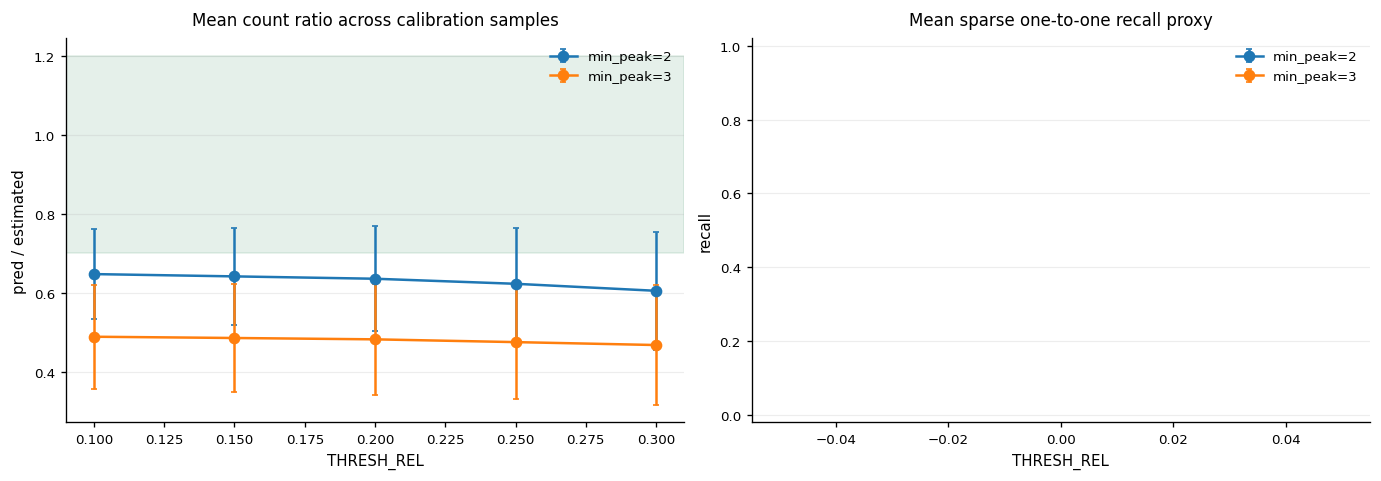

""


In [12]:
def load_geff_nodes(geff_path: Path) -> pd.DataFrame | None:
    if zarr is None or geff_path is None or not geff_path.exists():
        return None
    try:
        root = zarr.open_group(str(geff_path), mode='r')
        ids = np.asarray(root['nodes/ids'][:]).astype(np.int64) if 'nodes/ids' in root else np.arange(len(root['nodes/props/t/values'][:]))
        data = {
            'node_id': ids,
            't': np.asarray(root['nodes/props/t/values'][:]),
            'z': np.asarray(root['nodes/props/z/values'][:]),
            'y': np.asarray(root['nodes/props/y/values'][:]),
            'x': np.asarray(root['nodes/props/x/values'][:]),
        }
        return pd.DataFrame(data)
    except Exception:
        return None


def point_match_count(gt_xyz: np.ndarray, pred_xyz: np.ndarray, gate_um: float = CFG.MATCH_GATE_UM, scale: np.ndarray = SCALE) -> int:
    if len(gt_xyz) == 0 or len(pred_xyz) == 0:
        return 0
    dist = cdist(gt_xyz * scale, pred_xyz * scale)
    big = 1e6
    cost = np.where(dist <= gate_um, dist, big)
    row_ind, col_ind = linear_sum_assignment(cost)
    return int((cost[row_ind, col_ind] < big).sum())


def sampled_count_frame_indices(T: int, n: int | None, window: int = 5) -> np.ndarray:
    T = int(T)
    if T <= 0:
        return np.array([], dtype=np.int64)
    if n is None or int(n) >= T:
        return np.arange(T, dtype=np.int64)
    n = max(1, min(int(n), T))
    window = max(1, min(int(window), n, T))
    n_windows = max(1, int(np.ceil(n / window)))
    centers = np.linspace(0, T - 1, n_windows, dtype=np.int64)
    frames: list[int] = []
    for center in centers:
        start = int(np.clip(int(center) - window // 2, 0, max(0, T - window)))
        frames.extend(range(start, min(T, start + window)))
    return np.asarray(sorted(set(frames))[:n], dtype=np.int64)


def detect_centroids_for_frames(
    zarr_path: Path,
    shape: tuple[int, ...],
    dtype: np.dtype,
    frame_indices: list[int] | np.ndarray,
    cfg: CONFIG = CFG,
    warmup: int = 0,
) -> dict[int, np.ndarray]:
    target_frames = sorted(set(int(t) for t in frame_indices if 0 <= int(t) < int(shape[0])))
    if not target_frames:
        return {}
    target_set = set(target_frames)
    frames_to_run: set[int] = set()
    for t in target_frames:
        start = max(0, t - max(0, int(warmup)))
        frames_to_run.update(range(start, t + 1))
    outputs: dict[int, np.ndarray] = {}
    prev_count: int | None = None
    prev_t: int | None = None
    for t in sorted(frames_to_run):
        if prev_t is None or t != prev_t + 1:
            prev_count = None
        vol = load_volume(zarr_path, int(t), shape, dtype)
        coords, _ = detect_centroids_with_scores(vol, cfg, prev_count=prev_count)
        prev_count = len(coords)
        prev_t = int(t)
        if t in target_set:
            outputs[int(t)] = coords
    return outputs


def count_detected_nodes(name: str, cfg: CONFIG = CFG, max_frames: int | None = COUNT_SWEEP_FRAMES) -> dict:
    zarr_path = TRAIN_DIR / f'{name}.zarr'
    shape, dtype = read_zarr_meta(zarr_path)
    frame_indices = sampled_count_frame_indices(shape[0], max_frames, window=min(5, max_frames or 5))
    pred_by_frame = detect_centroids_for_frames(zarr_path, shape, dtype, frame_indices, cfg=cfg, warmup=0)
    pred_total = sum(len(pred_by_frame.get(int(t), [])) for t in frame_indices)
    n_frames = len(frame_indices)
    scale_factor = shape[0] / max(n_frames, 1)
    return {
        'name': name,
        'frames_counted': n_frames,
        'frame_indices': ','.join(map(str, frame_indices.tolist())),
        'frame_sampling': 'contiguous_windows',
        'pred_nodes_counted': pred_total,
        'pred_nodes_est_full': pred_total * scale_factor,
        'pred_nodes_per_frame': pred_total / max(n_frames, 1),
    }


def count_calibration_probe(names: list[str], cfg: CONFIG = CFG, limit: int = COUNT_CALIBRATION_SAMPLE_LIMIT, max_frames: int = COUNT_SWEEP_FRAMES) -> pd.DataFrame:
    rows = []
    for name in select_diverse_samples(names, limit):
        row = count_detected_nodes(name, cfg=cfg, max_frames=max_frames)
        est = read_estimated_nodes(TRAIN_DIR / f'{name}.geff')
        row['embryo'] = embryo_id(name)
        row['estimated_number_of_nodes'] = est
        row['pred_to_estimated_ratio'] = row['pred_nodes_est_full'] / est if np.isfinite(est) and est > 0 else np.nan
        rows.append(row)
    return pd.DataFrame(rows)


def detection_recall_proxy(name: str, cfg: CONFIG = CFG, max_frames: int = 10, max_dist_um: float | None = None) -> dict:
    if TRAIN_DIR is None:
        return {'error': 'TRAIN_DIR not found'}
    gt = load_geff_nodes(TRAIN_DIR / f'{name}.geff')
    if gt is None or len(gt) == 0:
        return {'error': 'GT nodes unavailable'}

    gate_um = cfg.MATCH_GATE_UM if max_dist_um is None else max_dist_um
    scale = np.array(cfg.SCALE, dtype=np.float64)
    zarr_path = TRAIN_DIR / f'{name}.zarr'
    shape, dtype = read_zarr_meta(zarr_path)
    frame_indices = sampled_gt_frames(gt, shape[0], max_frames)

    pred_by_frame = detect_centroids_for_frames(zarr_path, shape, dtype, frame_indices, cfg=cfg, warmup=2)
    matched = 0
    gt_total = 0
    pred_total = 0
    for t in frame_indices:
        pred = pred_by_frame.get(int(t), np.empty((0, 3), dtype=np.float64))
        pred_total += len(pred)
        gt_t = gt[gt['t'] == int(t)][['z', 'y', 'x']].to_numpy(dtype=np.float64)
        gt_total += len(gt_t)
        matched += point_match_count(gt_t, pred, gate_um=gate_um, scale=scale)

    n_frames = len(frame_indices)
    return {
        'name': name,
        'frames': n_frames,
        'frame_indices': ','.join(map(str, frame_indices)),
        'frame_sampling': 'annotated_frames_with_warmup',
        'video_frames': shape[0],
        'annotated_gt_nodes': gt_total,
        'pred_nodes': pred_total,
        'pred_nodes_est_full': pred_total * shape[0] / max(n_frames, 1),
        'gt_node_recall_proxy': matched / max(gt_total, 1),
        'matched_gt_nodes': matched,
        'pred_nodes_per_frame': pred_total / max(n_frames, 1),
        'annotated_gt_per_frame': gt_total / max(n_frames, 1),
    }


def rows_to_nodes_edges(pred_rows: list[dict] | pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    pred = pd.DataFrame(pred_rows, columns=SUBMISSION_COLUMNS) if isinstance(pred_rows, list) else pred_rows.copy()
    nodes = pred[pred['row_type'] == 'node'].copy()
    edges = pred[pred['row_type'] == 'edge'].copy()
    return nodes, edges


def match_nodes_by_frame(gt_nodes: pd.DataFrame, pred_nodes: pd.DataFrame, cfg: CONFIG = CFG) -> pd.DataFrame:
    rows = []
    scale = np.array(cfg.SCALE, dtype=np.float64)
    for t, gt_t in gt_nodes.groupby('t'):
        pred_t = pred_nodes[pred_nodes['t'] == int(t)]
        if len(gt_t) == 0 or len(pred_t) == 0:
            continue
        gt_xyz = gt_t[['z', 'y', 'x']].to_numpy(dtype=np.float64)
        pred_xyz = pred_t[['z', 'y', 'x']].to_numpy(dtype=np.float64)
        dist = cdist(pred_xyz * scale, gt_xyz * scale)
        big = 1e6
        cost = np.where(dist <= cfg.MATCH_GATE_UM, dist, big)
        pred_ind, gt_ind = linear_sum_assignment(cost)
        for pi, gi in zip(pred_ind, gt_ind):
            if cost[pi, gi] < big:
                rows.append({
                    'pred_node_id': int(pred_t.iloc[pi]['node_id']),
                    'gt_node_id': int(gt_t.iloc[gi]['node_id']),
                    't': int(t),
                    'dist_um': float(cost[pi, gi]),
                })
    return pd.DataFrame(rows, columns=['pred_node_id', 'gt_node_id', 't', 'dist_um'])


def local_edge_jaccard_proxy(gt_nodes: pd.DataFrame, gt_edges: pd.DataFrame, pred_rows: list[dict] | pd.DataFrame, cfg: CONFIG = CFG) -> dict:
    pred_nodes, pred_edges = rows_to_nodes_edges(pred_rows)
    matches = match_nodes_by_frame(gt_nodes, pred_nodes, cfg)
    pred_to_gt = dict(zip(matches['pred_node_id'], matches['gt_node_id'])) if len(matches) else {}
    gt_edge_set = set(map(tuple, gt_edges[['source_id', 'target_id']].astype(int).to_numpy())) if len(gt_edges) else set()

    mapped_pred_edges = set()
    for s, t in pred_edges[['source_id', 'target_id']].itertuples(index=False):
        if int(s) in pred_to_gt and int(t) in pred_to_gt:
            mapped_pred_edges.add((int(pred_to_gt[int(s)]), int(pred_to_gt[int(t)])))

    tp = len(mapped_pred_edges & gt_edge_set)
    fp = len(mapped_pred_edges - gt_edge_set)
    fn = len(gt_edge_set - mapped_pred_edges)
    denom = tp + fp + fn
    return {'edge_tp': tp, 'edge_fp': fp, 'edge_fn': fn, 'edge_jaccard_proxy': tp / denom if denom else np.nan}


def local_division_proxy(gt_nodes: pd.DataFrame, gt_edges: pd.DataFrame, pred_rows: list[dict] | pd.DataFrame, cfg: CONFIG = CFG) -> dict:
    pred_nodes, pred_edges = rows_to_nodes_edges(pred_rows)
    matches = match_nodes_by_frame(gt_nodes, pred_nodes, cfg)
    pred_to_gt = dict(zip(matches['pred_node_id'], matches['gt_node_id'])) if len(matches) else {}

    gt_counts = gt_edges['source_id'].value_counts() if len(gt_edges) else pd.Series(dtype=int)
    pred_counts = pred_edges['source_id'].value_counts() if len(pred_edges) else pd.Series(dtype=int)
    gt_divs = set(int(k) for k, v in gt_counts.items() if v >= 2)
    pred_divs = set(int(k) for k, v in pred_counts.items() if v >= 2)
    mapped_pred_divs = set(pred_to_gt[p] for p in pred_divs if p in pred_to_gt)

    tp = len(mapped_pred_divs & gt_divs)
    fp = len(mapped_pred_divs - gt_divs)
    fn = len(gt_divs - mapped_pred_divs)
    denom = tp + fp + fn
    return {
        'gt_divisions': len(gt_divs),
        'pred_divisions': len(pred_divs),
        'division_tp': tp,
        'division_fp': fp,
        'division_fn': fn,
        'division_proxy': tp / denom if denom else np.nan,
    }


def local_proxy_for_sample(name: str, cfg: CONFIG = CFG) -> dict | None:
    gt_nodes, gt_edges = load_geff_raw(TRAIN_DIR / f'{name}.geff')
    if gt_nodes is None:
        return None

    # Pre-prune graph is useful when PRUNE_ISOLATED_NODES=True. Otherwise reuse the same run.
    if cfg.PRUNE_ISOLATED_NODES:
        cfg_pre = CONFIG(**{**asdict(cfg), 'PRUNE_ISOLATED_NODES': False})
        pred_rows_pre, n_nodes_pre, _ = process_dataset(TRAIN_DIR, name, cfg_pre)
        pred_rows, n_nodes, n_divisions = process_dataset(TRAIN_DIR, name, cfg)
    else:
        pred_rows, n_nodes, n_divisions = process_dataset(TRAIN_DIR, name, cfg)
        pred_rows_pre, n_nodes_pre = pred_rows, n_nodes

    pred_nodes_pre, _ = rows_to_nodes_edges(pred_rows_pre)
    matches_pre = match_nodes_by_frame(gt_nodes, pred_nodes_pre, cfg)
    pred_nodes, _ = rows_to_nodes_edges(pred_rows)
    matches = match_nodes_by_frame(gt_nodes, pred_nodes, cfg)
    edge_stats = local_edge_jaccard_proxy(gt_nodes, gt_edges, pred_rows, cfg)
    div_stats = local_division_proxy(gt_nodes, gt_edges, pred_rows, cfg)
    est = read_estimated_nodes(TRAIN_DIR / f'{name}.geff')
    stats = PROCESS_STATS_CACHE.get(name, {})
    out = {
        'experiment_tag': cfg.EXPERIMENT_TAG,
        'name': name,
        'embryo': embryo_id(name),
        'pred_nodes_pre_prune': n_nodes_pre,
        'pred_nodes': n_nodes,
        'estimated_number_of_nodes': est,
        'count_ratio_pre_prune': n_nodes_pre / est if np.isfinite(est) and est > 0 else np.nan,
        'count_ratio': n_nodes / est if np.isfinite(est) and est > 0 else np.nan,
        'sparse_gt_nodes': len(gt_nodes),
        'matched_sparse_gt_nodes_pre_prune': len(matches_pre),
        'matched_sparse_gt_nodes': len(matches),
        'sparse_recall_pre_prune': len(matches_pre) / max(len(gt_nodes), 1),
        'sparse_node_recall': len(matches) / max(len(gt_nodes), 1),
        'pred_division_like_sources': n_divisions,
        'removed_isolated': stats.get('removed_isolated', 0),
        'nodes_before_prune': stats.get('nodes_before_prune', n_nodes_pre),
        'nodes_after_prune': stats.get('nodes_after_prune', n_nodes),
    }
    out.update(edge_stats)
    out.update(div_stats)
    return out


def run_local_proxy_scores(names: list[str], cfg: CONFIG = CFG, limit: int = 3) -> pd.DataFrame:
    rows = []
    for name in select_diverse_samples(names, limit):
        row = local_proxy_for_sample(name, cfg)
        if row is not None:
            rows.append(row)
    return pd.DataFrame(rows)


def write_experiment_log(scores: pd.DataFrame, cfg: CONFIG = CFG, path: str = 'experiment_log.csv') -> None:
    if not cfg.WRITE_EXPERIMENT_LOG or not len(scores):
        return
    summary = {
        'experiment_tag': cfg.EXPERIMENT_TAG,
        'detection_mode': cfg.DETECTION_MODE,
        'thresh_rel': cfg.THRESH_REL,
        'min_peak_dist': cfg.MIN_PEAK_DIST,
        'final_nms_radius_um': cfg.FINAL_NMS_RADIUS_UM,
        'use_topk_count_control': cfg.USE_TOPK_COUNT_CONTROL,
        'max_link_dist': cfg.MAX_LINK_DIST,
        'use_motion_cost': cfg.USE_MOTION_COST,
        'detect_divisions': cfg.DETECT_DIVISIONS,
        'div_use_midpoint': cfg.DIV_USE_MIDPOINT,
        'local_count_ratio_mean': scores['count_ratio'].mean() if 'count_ratio' in scores else np.nan,
        'local_sparse_recall_mean': scores['sparse_node_recall'].mean() if 'sparse_node_recall' in scores else np.nan,
        'local_edge_proxy_mean': scores['edge_jaccard_proxy'].mean() if 'edge_jaccard_proxy' in scores else np.nan,
        'local_division_proxy_mean': scores['division_proxy'].mean() if 'division_proxy' in scores else np.nan,
    }
    df = pd.DataFrame([summary])
    exists = Path(path).exists()
    df.to_csv(path, mode='a', header=not exists, index=False)


def detection_calibration_sweep(
    name: str,
    rel_values=(0.10, 0.15, 0.20, 0.25, 0.30),
    min_peak_values=(2, 3),
    max_frames: int = COUNT_SWEEP_FRAMES,
) -> pd.DataFrame:
    rows = []
    est = read_estimated_nodes(TRAIN_DIR / f'{name}.geff')
    for thresh_rel in rel_values:
        for min_peak_dist in min_peak_values:
            cfg = CONFIG(**{**asdict(CFG), 'DETECTION_MODE': 'single', 'THRESH_REL': float(thresh_rel), 'MIN_PEAK_DIST': int(min_peak_dist)})
            counts = count_detected_nodes(name, cfg=cfg, max_frames=max_frames)
            proxy = detection_recall_proxy(name, cfg=cfg, max_frames=max_frames)
            pred_nodes_est_full = counts.get('pred_nodes_est_full', np.nan)
            rows.append({
                'name': name,
                'embryo': embryo_id(name),
                'THRESH_REL': thresh_rel,
                'MIN_PEAK_DIST': min_peak_dist,
                'frames': counts.get('frames_counted', max_frames),
                'count_frame_indices': counts.get('frame_indices', ''),
                'recall_frame_indices': proxy.get('frame_indices', ''),
                'pred_nodes_est_full': pred_nodes_est_full,
                'estimated_number_of_nodes': est,
                'pred_to_estimated_ratio': pred_nodes_est_full / est if np.isfinite(est) and est > 0 else np.nan,
                'sparse_recall_proxy': proxy.get('gt_node_recall_proxy', np.nan),
                'nodes_per_frame': counts.get('pred_nodes_per_frame', np.nan),
                'matched_gt_nodes': proxy.get('matched_gt_nodes', np.nan),
                'annotated_gt_nodes': proxy.get('annotated_gt_nodes', np.nan),
            })
    return pd.DataFrame(rows).sort_values(['MIN_PEAK_DIST', 'THRESH_REL']).reset_index(drop=True)


def summarize_detection_sweep(sweep_all: pd.DataFrame) -> pd.DataFrame:
    if not len(sweep_all):
        return pd.DataFrame()
    summary = (
        sweep_all
        .groupby(['THRESH_REL', 'MIN_PEAK_DIST'], as_index=False)
        .agg(
            samples=('name', 'nunique'),
            pred_to_estimated_ratio_mean=('pred_to_estimated_ratio', 'mean'),
            pred_to_estimated_ratio_std=('pred_to_estimated_ratio', 'std'),
            sparse_recall_proxy_mean=('sparse_recall_proxy', 'mean'),
            sparse_recall_proxy_std=('sparse_recall_proxy', 'std'),
            nodes_per_frame_mean=('nodes_per_frame', 'mean'),
        )
    )
    return summary.sort_values(['sparse_recall_proxy_mean', 'pred_to_estimated_ratio_mean'], ascending=[False, True]).reset_index(drop=True)


if train_names and RUN_COUNT_SWEEP:
    calibration_names = select_diverse_samples(train_names, COUNT_CALIBRATION_SAMPLE_LIMIT)
    display(pd.DataFrame({'calibration_sample': calibration_names, 'embryo': [embryo_id(n) for n in calibration_names]}))

    calibration = count_calibration_probe(calibration_names, limit=len(calibration_names), max_frames=COUNT_SWEEP_FRAMES)
    if len(calibration):
        display(calibration)

    proxy = detection_recall_proxy(calibration_names[0], cfg=CFG, max_frames=COUNT_SWEEP_FRAMES)
    print(proxy)

    sweep_parts = [detection_calibration_sweep(name, max_frames=COUNT_SWEEP_FRAMES) for name in calibration_names]
    sweep = pd.concat(sweep_parts, ignore_index=True) if sweep_parts else pd.DataFrame()
    sweep_summary = summarize_detection_sweep(sweep)
    display(sweep)
    display(sweep_summary)

    if len(sweep_summary):
        fig, axes = plt.subplots(1, 2, figsize=(11.4, 3.9), constrained_layout=True)
        for min_peak_dist, group in sweep_summary.groupby('MIN_PEAK_DIST'):
            group = group.sort_values('THRESH_REL')
            axes[0].errorbar(group['THRESH_REL'], group['pred_to_estimated_ratio_mean'], yerr=group['pred_to_estimated_ratio_std'].fillna(0), marker='o', capsize=2, label=f'min_peak={min_peak_dist}')
            axes[1].errorbar(group['THRESH_REL'], group['sparse_recall_proxy_mean'], yerr=group['sparse_recall_proxy_std'].fillna(0), marker='o', capsize=2, label=f'min_peak={min_peak_dist}')
        axes[0].axhspan(0.7, 1.2, color=PLOT_COLORS['green'], alpha=0.12)
        axes[0].legend(frameon=False)
        style_axis(axes[0], 'Mean count ratio across calibration samples', 'THRESH_REL', 'pred / estimated')
        axes[1].legend(frameon=False)
        style_axis(axes[1], 'Mean sparse one-to-one recall proxy', 'THRESH_REL', 'recall')
        axes[1].set_ylim(-0.02, 1.02)
        plt.show()
elif train_names:
    print('RUN_COUNT_SWEEP=False; detection calibration proxy skipped.')
else:
    print('No train data yet; proxy skipped.')

if train_names and RUN_LOCAL_PROXY:
    local_proxy_scores = run_local_proxy_scores(train_names, CFG, limit=CFG.LOCAL_PROXY_SAMPLE_LIMIT)
    display(local_proxy_scores)
    write_experiment_log(local_proxy_scores, CFG)
elif train_names:
    print('RUN_LOCAL_PROXY=False; local graph proxy skipped.')


## Reference CSV Schema Check

Before writing predictions, the expected CSV header is compared with `sample_submission.csv` when that file is available. This catches column-order mistakes early; the detailed row-level audit is performed later after each dataset is processed.


In [13]:
EXPECTED_CSV_HEADER = ['id', 'dataset', 'row_type', 'node_id', 't', 'z', 'y', 'x', 'source_id', 'target_id']

sample_path = SAMPLE_SUBMISSION_PATH
if sample_path is not None and sample_path.exists():
    sample_header = pd.read_csv(sample_path, nrows=0).columns.tolist()
    print('sample_submission header:', sample_header)
    print('expected header:         ', EXPECTED_CSV_HEADER)
    assert sample_header == EXPECTED_CSV_HEADER, 'sample_submission header differs from expected format'
    display(pd.read_csv(sample_path, nrows=5))
else:
    print('sample_submission.csv not found in DATA_ROOT; using documented expected header.')
    print(EXPECTED_CSV_HEADER)


sample_submission header: ['id', 'dataset', 'row_type', 'node_id', 't', 'z', 'y', 'x', 'source_id', 'target_id']
expected header:          ['id', 'dataset', 'row_type', 'node_id', 't', 'z', 'y', 'x', 'source_id', 'target_id']


,id,dataset,row_type,node_id,t,z,y,x,source_id,target_id
0,0,44b6_0113de3b,node,1,0,32,128,128,-1,-1
1,1,44b6_0113de3b,node,2,1,32,128,128,-1,-1
2,2,44b6_0113de3b,node,3,2,32,128,128,-1,-1
3,3,44b6_0113de3b,edge,-1,-1,-1,-1,-1,1,2
4,4,44b6_0113de3b,edge,-1,-1,-1,-1,-1,2,3


## Build the Output Graph CSV

This section processes every dataset in the test split and writes `submission.csv` with node rows and edge rows. The writer is streaming: each dataset is converted to graph rows, audited, and appended without holding the full output graph in memory. `SUBMIT_MODE=True` keeps the final path lightweight: schema checks and CSV writing remain active, while development displays, plots, calibration sweeps, and local proxy scoring are opt-in.


### Output Format Guardrails

The final CSV must have this exact header after saving:

```text
id,dataset,row_type,node_id,t,z,y,x,source_id,target_id
```

Rows follow two sentinel conventions:

| row type | filled fields | sentinel fields |
|---|---|---|
| `node` | `dataset,node_id,t,z,y,x` | `source_id=-1,target_id=-1` |
| `edge` | `dataset,source_id,target_id` | `node_id=t=z=y=x=-1` |

For every dataset, each edge endpoint must reference a node ID from the same dataset. The audit below also checks column order, missing datasets, invalid sentinels, duplicate node IDs, integer-like fields, and coordinate bounds.


In [14]:
SUBMISSION_COLUMNS = ['dataset', 'row_type', 'node_id', 't', 'z', 'y', 'x', 'source_id', 'target_id']
PROCESS_STATS_CACHE: dict[str, dict] = {}


def _clip_int(value, low: int, high: int) -> int:
    return int(np.clip(int(round(value)), low, high))


def _add_edge_row(rows: list[dict], dataset: str, source_id: int, target_id: int) -> None:
    rows.append({
        'dataset': dataset,
        'row_type': 'edge',
        'node_id': -1,
        't': -1,
        'z': -1,
        'y': -1,
        'x': -1,
        'source_id': int(source_id),
        'target_id': int(target_id),
    })


def prune_isolated_nodes(node_rows: list[dict], edge_rows: list[dict], node_scores: dict[int, float], cfg: CONFIG = CFG) -> tuple[list[dict], list[dict], dict]:
    stats = {
        'nodes_before_prune': len(node_rows),
        'edges_before_prune': len(edge_rows),
        'nodes_after_prune': len(node_rows),
        'edges_after_prune': len(edge_rows),
        'removed_isolated': 0,
    }
    if not cfg.PRUNE_ISOLATED_NODES or not node_rows:
        return node_rows, edge_rows, stats

    incident = set()
    for edge in edge_rows:
        incident.add(int(edge['source_id']))
        incident.add(int(edge['target_id']))
    keep = set(incident)

    if cfg.KEEP_STRONG_ISOLATED and node_scores:
        score_vals = np.asarray(list(node_scores.values()), dtype=np.float64)
        floor = float(np.quantile(score_vals, cfg.STRONG_ISOLATED_QUANTILE))
        keep.update(int(nid) for nid, score in node_scores.items() if float(score) >= floor)

    if not keep:
        strongest = max(node_scores, key=node_scores.get) if node_scores else int(node_rows[0]['node_id'])
        keep.add(int(strongest))

    kept_nodes = [row for row in node_rows if int(row['node_id']) in keep]
    kept_ids = {int(row['node_id']) for row in kept_nodes}
    kept_edges = [row for row in edge_rows if int(row['source_id']) in kept_ids and int(row['target_id']) in kept_ids]

    if not kept_nodes:
        kept_nodes = [max(node_rows, key=lambda row: node_scores.get(int(row['node_id']), 0.0))]
        kept_ids = {int(kept_nodes[0]['node_id'])}
        kept_edges = [row for row in edge_rows if int(row['source_id']) in kept_ids and int(row['target_id']) in kept_ids]

    stats.update({
        'nodes_after_prune': len(kept_nodes),
        'edges_after_prune': len(kept_edges),
        'removed_isolated': len(node_rows) - len(kept_nodes),
    })
    return kept_nodes, kept_edges, stats


def process_dataset(split_dir: Path, name: str, cfg: CONFIG = CFG) -> tuple[list[dict], int, int]:
    zarr_path = split_dir / f'{name}.zarr'
    shape, dtype = read_zarr_meta(zarr_path)
    n_t, n_z, n_y, n_x = shape

    node_rows: list[dict] = []
    edge_rows: list[dict] = []
    node_scores: dict[int, float] = {}
    node_id = 1
    frame_ids: list[list[int]] = []
    frame_centroids: list[np.ndarray] = []
    prev_count: int | None = None

    for t in range(n_t):
        vol = load_volume(zarr_path, t, shape, dtype)
        cents, scores = detect_centroids_with_scores(vol, cfg, prev_count=prev_count)
        prev_count = len(cents)
        curr_ids = list(range(node_id, node_id + len(cents)))
        node_id += len(cents)
        frame_ids.append(curr_ids)
        frame_centroids.append(cents)

        for nid, score, (z, y, x) in zip(curr_ids, scores, cents):
            node_scores[int(nid)] = float(score)
            node_rows.append({
                'dataset': name,
                'row_type': 'node',
                'node_id': int(nid),
                't': int(t),
                'z': _clip_int(z, 0, n_z - 1),
                'y': _clip_int(y, 0, n_y - 1),
                'x': _clip_int(x, 0, n_x - 1),
                'source_id': -1,
                'target_id': -1,
            })

    velocity_by_id: dict[int, np.ndarray] = {}
    position_by_id: dict[int, np.ndarray] = {}
    for ids, xyz in zip(frame_ids, frame_centroids):
        for nid, point in zip(ids, xyz):
            position_by_id[int(nid)] = np.asarray(point, dtype=np.float64)

    edge_set: set[tuple[int, int]] = set()
    for t in range(1, n_t):
        prev_ids = frame_ids[t - 1]
        curr_ids = frame_ids[t]
        prev_xyz = frame_centroids[t - 1]
        curr_xyz = frame_centroids[t]
        next_xyz = frame_centroids[t + 1] if t + 1 < n_t else None
        prev_velocity = np.asarray([velocity_by_id.get(int(pid), np.zeros(3, dtype=np.float64)) for pid in prev_ids], dtype=np.float64)
        edges = link_with_divisions(prev_ids, prev_xyz, curr_ids, curr_xyz, next_xyz=next_xyz, prev_velocity_phys=prev_velocity, cfg=cfg)

        for source_id, target_id in edges:
            pair = (int(source_id), int(target_id))
            if pair in edge_set:
                continue
            edge_set.add(pair)
            _add_edge_row(edge_rows, name, source_id, target_id)
            if source_id in position_by_id and target_id in position_by_id:
                velocity_by_id[int(target_id)] = (position_by_id[int(target_id)] - position_by_id[int(source_id)]) * np.array(cfg.SCALE, dtype=np.float64)


    if cfg.USE_GAP_LINKS:
        for t in range(n_t):
            source_ids = frame_ids[t]
            source_xyz = frame_centroids[t]
            if len(source_ids) == 0:
                continue
            source_phys = source_xyz * np.array(cfg.SCALE, dtype=np.float64)
            for gap in range(2, int(cfg.MAX_GAP) + 1):
                u = t + gap
                if u >= n_t or len(frame_ids[u]) == 0:
                    continue
                target_ids = frame_ids[u]
                target_xyz = frame_centroids[u]
                target_phys = target_xyz * np.array(cfg.SCALE, dtype=np.float64)
                tree = cKDTree(target_phys)
                for src_id, src_point in zip(source_ids, source_phys):
                    close = tree.query_ball_point(src_point, r=cfg.GAP_LINK_DIST_PER_FRAME * gap)
                    if len(close) != 1:
                        continue
                    target_id = int(target_ids[close[0]])
                    pair = (int(src_id), target_id)
                    if pair not in edge_set:
                        edge_set.add(pair)
                        _add_edge_row(edge_rows, name, pair[0], pair[1])

    if not node_rows:
        node_rows.append({
            'dataset': name,
            'row_type': 'node',
            'node_id': 1,
            't': 0,
            'z': n_z // 2,
            'y': n_y // 2,
            'x': n_x // 2,
            'source_id': -1,
            'target_id': -1,
        })
        node_scores[1] = 0.0
        node_id = 2

    nodes_before = len(node_rows)
    edges_before = len(edge_rows)
    division_sources_before = sum(1 for count in Counter(row['source_id'] for row in edge_rows).values() if count >= 2)
    node_rows, edge_rows, prune_stats = prune_isolated_nodes(node_rows, edge_rows, node_scores, cfg)
    division_sources_after = sum(1 for count in Counter(row['source_id'] for row in edge_rows).values() if count >= 2)
    rows = node_rows + edge_rows

    stats = {
        'nodes_before_prune': nodes_before,
        'edges_before_prune': edges_before,
        'nodes_after_prune': len(node_rows),
        'edges_after_prune': len(edge_rows),
        'removed_isolated': max(0, nodes_before - len(node_rows)),
        'division_sources_before_prune': division_sources_before,
        'division_sources_after_prune': division_sources_after,
        'nodes_per_frame_before_prune': nodes_before / max(n_t, 1),
        'nodes_per_frame_after_prune': len(node_rows) / max(n_t, 1),
    }
    stats.update(prune_stats)
    PROCESS_STATS_CACHE[name] = stats
    return rows, len(node_rows), division_sources_after


def expected_submission_header() -> list[str]:
    return ['id'] + SUBMISSION_COLUMNS


def audit_submission(submission: pd.DataFrame, expected_datasets: list[str], split_dir: Path) -> pd.DataFrame:
    assert list(submission.columns) == SUBMISSION_COLUMNS, 'wrong column order'
    assert not submission.isna().any().any(), 'submission contains NaN'
    assert set(submission['row_type']).issubset({'node', 'edge'}), 'invalid row_type'

    missing = sorted(set(expected_datasets) - set(submission['dataset'].unique()))
    assert not missing, f'missing datasets: {missing[:5]}'

    nodes = submission[submission['row_type'] == 'node']
    edges = submission[submission['row_type'] == 'edge']
    assert len(nodes) > 0, 'no node rows produced'

    assert (nodes[['node_id', 't', 'z', 'y', 'x']] >= 0).all().all(), 'node ids/t/coords must be non-negative'
    assert (nodes[['source_id', 'target_id']] == -1).all().all(), 'node rows must have source_id=target_id=-1'
    if len(edges):
        assert (edges[['node_id', 't', 'z', 'y', 'x']] == -1).all().all(), 'edge sentinel fields must be -1'
        assert (edges[['source_id', 'target_id']] > 0).all().all(), 'edge endpoints must be positive node ids'

    audit_rows = []
    for ds, group in submission.groupby('dataset'):
        shape, _ = read_zarr_meta(split_dir / f'{ds}.zarr')
        n_t, n_z, n_y, n_x = shape
        ds_nodes = group[group['row_type'] == 'node']
        ds_edges = group[group['row_type'] == 'edge']
        node_ids = set(ds_nodes['node_id'])

        assert ds_nodes['node_id'].is_unique, f'duplicate node_id in {ds}'
        assert ds_edges['source_id'].isin(node_ids).all(), f'dangling source in {ds}'
        assert ds_edges['target_id'].isin(node_ids).all(), f'dangling target in {ds}'
        assert ds_nodes['t'].between(0, n_t - 1).all(), f't out of bounds in {ds}'
        assert ds_nodes['z'].between(0, n_z - 1).all(), f'z out of bounds in {ds}'
        assert ds_nodes['y'].between(0, n_y - 1).all(), f'y out of bounds in {ds}'
        assert ds_nodes['x'].between(0, n_x - 1).all(), f'x out of bounds in {ds}'

        source_counts = ds_edges['source_id'].value_counts()
        stats = PROCESS_STATS_CACHE.get(ds, {})
        audit_rows.append({
            'dataset': ds,
            'nodes': len(ds_nodes),
            'edges': len(ds_edges),
            'division_like_sources': int((source_counts >= 2).sum()),
            'T': n_t,
            'nodes_per_frame': len(ds_nodes) / max(n_t, 1),
            'nodes_before_prune': stats.get('nodes_before_prune', len(ds_nodes)),
            'nodes_after_prune': stats.get('nodes_after_prune', len(ds_nodes)),
            'edges_before_prune': stats.get('edges_before_prune', len(ds_edges)),
            'edges_after_prune': stats.get('edges_after_prune', len(ds_edges)),
            'removed_isolated': stats.get('removed_isolated', 0),
            'nodes_per_frame_before_prune': stats.get('nodes_per_frame_before_prune', len(ds_nodes) / max(n_t, 1)),
            'nodes_per_frame_after_prune': stats.get('nodes_per_frame_after_prune', len(ds_nodes) / max(n_t, 1)),
        })

    return pd.DataFrame(audit_rows).sort_values('dataset').reset_index(drop=True)


def write_rows_to_csv(writer, start_id: int, rows: list[dict]) -> int:
    row_id = start_id
    for row in rows:
        writer.writerow([row_id] + [row[col] for col in SUBMISSION_COLUMNS])
        row_id += 1
    return row_id


def write_streaming_submission(dataset_names: list[str], split_dir: Path, path: str = 'submission.csv', cfg: CONFIG = CFG) -> tuple[pd.DataFrame, dict]:
    audit_rows = []
    row_id = 0
    n_nodes_total = 0
    n_edges_total = 0
    t0 = time.time()

    with open(path, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(expected_submission_header())

        for i, name in enumerate(dataset_names, 1):
            rows, n_nodes, n_divisions = process_dataset(split_dir, name, cfg)
            ds_submission = pd.DataFrame(rows, columns=SUBMISSION_COLUMNS)
            ds_audit = audit_submission(ds_submission, [name], split_dir)
            audit_rows.extend(ds_audit.to_dict('records'))

            row_id = write_rows_to_csv(writer, row_id, rows)
            n_edges = int((ds_submission['row_type'] == 'edge').sum())
            n_nodes_total += int(n_nodes)
            n_edges_total += n_edges

            elapsed = time.time() - t0
            projected_total_s = elapsed / i * len(dataset_names)
            print(f'[{i}/{len(dataset_names)}] {short_label(name, 24)}: {n_nodes} nodes, {n_divisions} divisions, elapsed={elapsed:.0f}s, projected={projected_total_s/3600:.2f}h')
            if projected_total_s > cfg.TIME_BUDGET_S:
                print(f'WARNING: projected runtime exceeds configured budget ({cfg.TIME_BUDGET_S/3600:.1f}h)')

    header = pd.read_csv(path, nrows=0).columns.tolist()
    assert header == expected_submission_header(), f'wrong CSV header: {header}'

    audit = pd.DataFrame(audit_rows).sort_values('dataset').reset_index(drop=True) if audit_rows else pd.DataFrame()
    missing = sorted(set(dataset_names) - set(audit['dataset'].unique())) if len(audit) else list(dataset_names)
    assert not missing, f'missing datasets after streaming write: {missing[:5]}'

    summary = {
        'experiment_tag': cfg.EXPERIMENT_TAG,
        'rows': row_id,
        'nodes': n_nodes_total,
        'edges': n_edges_total,
        'datasets': len(dataset_names),
        'path': path,
    }
    return audit, summary


[1/4] 44b6_0113de3b: 20449 nodes, 12 divisions, elapsed=22s, projected=0.02h
[2/4] 44b6_0b24845f: 11379 nodes, 16 divisions, elapsed=43s, projected=0.02h
[3/4] 6bba_05b6850b: 4172 nodes, 2 divisions, elapsed=58s, projected=0.02h
[4/4] 6bba_05db0fb1: 29775 nodes, 28 divisions, elapsed=83s, projected=0.02h
Rows: 127025 | nodes: 65775 | edges: 61250 | datasets: 4
All submission checks passed.


,id,dataset,row_type,node_id,t,z,y,x,source_id,target_id
0,0,44b6_0113de3b,node,1,0,58,137,202,-1,-1
1,1,44b6_0113de3b,node,2,0,61,113,218,-1,-1
2,2,44b6_0113de3b,node,3,0,41,6,173,-1,-1
3,3,44b6_0113de3b,node,4,0,48,102,170,-1,-1
4,4,44b6_0113de3b,node,5,0,35,93,130,-1,-1


,nodes,edges,division_like_sources,T,nodes_per_frame,nodes_before_prune,nodes_after_prune,edges_before_prune,edges_after_prune,removed_isolated,nodes_per_frame_before_prune,nodes_per_frame_after_prune
count,4.000000,4.00000,4.000000,4.0,4.000000,4.000000,4.000000,4.00000,4.00000,4.000000,4.000000,4.000000
mean,16443.750000,15312.50000,14.500000,100.0,164.437500,16811.000000,16443.750000,15312.50000,15312.50000,367.250000,168.110000,164.437500
std,11105.731174,10743.07487,10.754844,0.0,111.057312,11111.778945,11105.731174,10743.07487,10743.07487,369.507217,111.117789,111.057312
min,4172.000000,3920.00000,2.000000,100.0,41.720000,4248.000000,4172.000000,3920.00000,3920.00000,76.000000,42.480000,41.720000
25%,9577.250000,8144.75000,9.500000,100.0,95.772500,10263.000000,9577.250000,8144.75000,8144.75000,122.500000,102.630000,95.772500
50%,15914.000000,14594.00000,14.000000,100.0,159.140000,16427.500000,15914.000000,14594.00000,14594.00000,252.000000,164.275000,159.140000
75%,22780.500000,21761.75000,19.000000,100.0,227.805000,22975.500000,22780.500000,21761.75000,21761.75000,496.750000,229.755000,227.805000
max,29775.000000,28142.00000,28.000000,100.0,297.750000,30141.000000,29775.000000,28142.00000,28142.00000,889.000000,301.410000,297.750000


,dataset,nodes,edges,division_like_sources,T,nodes_per_frame,nodes_before_prune,nodes_after_prune,edges_before_prune,edges_after_prune,removed_isolated,nodes_per_frame_before_prune,nodes_per_frame_after_prune
0,44b6_0113de3b,20449,19635,12,100,204.49,20587,20449,19635,19635,138,205.87,204.49
1,44b6_0b24845f,11379,9553,16,100,113.79,12268,11379,9553,9553,889,122.68,113.79
2,6bba_05b6850b,4172,3920,2,100,41.72,4248,4172,3920,3920,76,42.48,41.72
3,6bba_05db0fb1,29775,28142,28,100,297.75,30141,29775,28142,28142,366,301.41,297.75


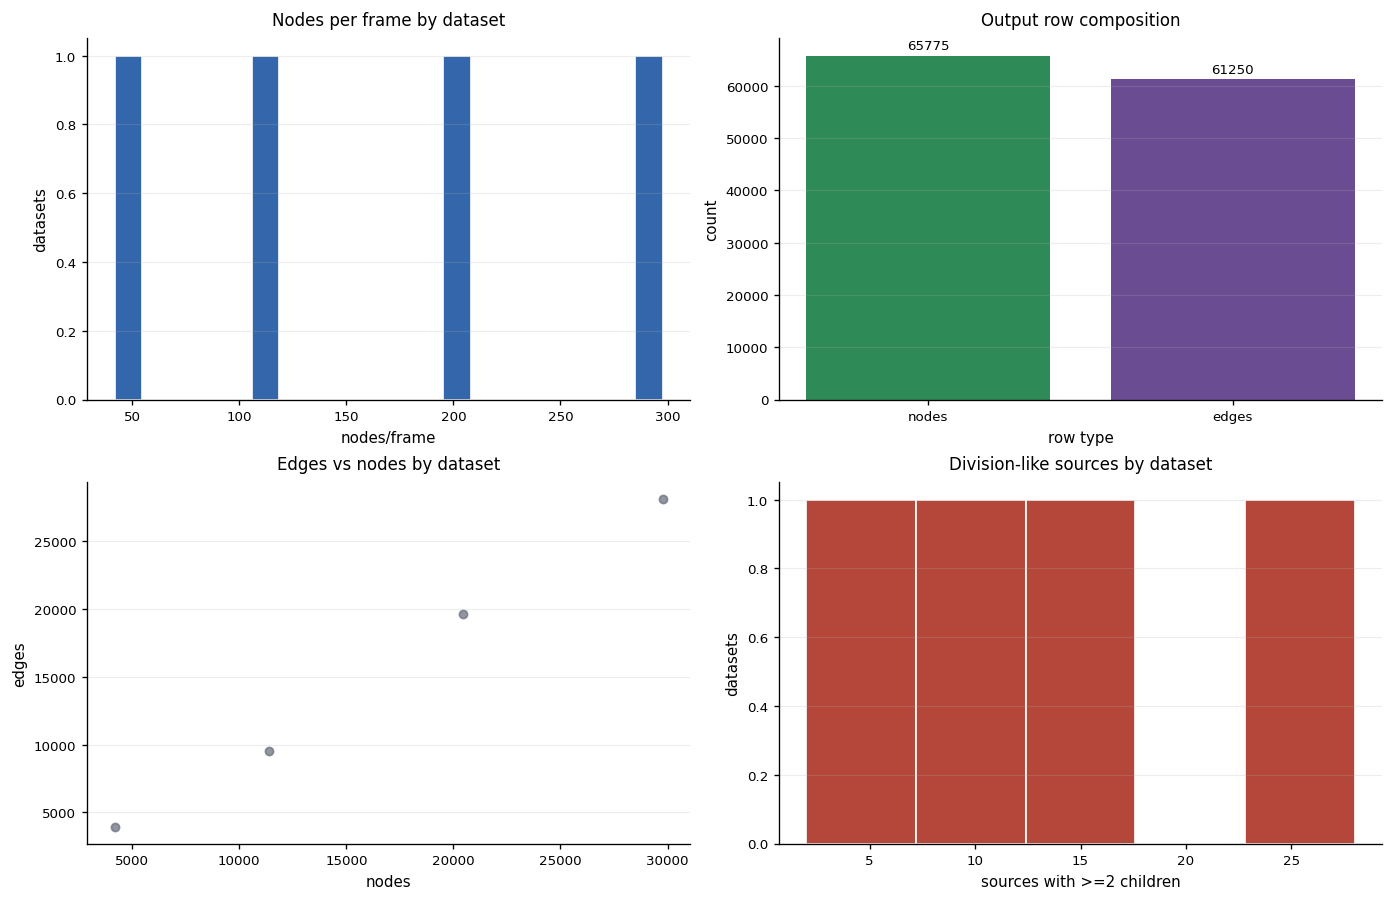

In [15]:
if not test_names:
    print('No test data found; submission generation skipped.')
else:
    names = test_names[:SUBMISSION_LIMIT] if SUBMISSION_LIMIT is not None else test_names
    audit, submit_summary = write_streaming_submission(names, TEST_DIR, 'submission.csv', CFG)

    print(f"Rows: {submit_summary['rows']} | nodes: {submit_summary['nodes']} | edges: {submit_summary['edges']} | datasets: {submit_summary['datasets']}")
    print('All submission checks passed.')

    if RUN_SUBMISSION_DISPLAY:
        submission_preview = pd.read_csv('submission.csv', nrows=5)
        display(submission_preview)
        display(audit.describe())
        display(audit.head())
    else:
        print('RUN_SUBMISSION_DISPLAY=False; lightweight submission display skipped.')

    if RUN_SUBMISSION_PLOTS and len(audit):
        fig, axes = plt.subplots(2, 2, figsize=(11.5, 7.4), constrained_layout=True)
        axes = axes.ravel()

        audit['nodes_per_frame'].plot(kind='hist', bins=20, ax=axes[0], color=PLOT_COLORS['blue'], edgecolor='white')
        style_axis(axes[0], 'Nodes per frame by dataset', 'nodes/frame', 'datasets')

        bars = axes[1].bar(['nodes', 'edges'], [submit_summary['nodes'], submit_summary['edges']], color=[PLOT_COLORS['green'], PLOT_COLORS['purple']])
        annotate_bars(axes[1], bars)
        style_axis(axes[1], 'Output row composition', 'row type', 'count')

        axes[2].scatter(audit['nodes'], audit['edges'], s=24, alpha=0.75, color=PLOT_COLORS['gray'])
        style_axis(axes[2], 'Edges vs nodes by dataset', 'nodes', 'edges')

        div_vals = audit['division_like_sources'].dropna()
        if len(div_vals):
            axes[3].hist(div_vals, bins=min(20, max(4, div_vals.nunique() + 1)), color=PLOT_COLORS['red'], edgecolor='white')
            style_axis(axes[3], 'Division-like sources by dataset', 'sources with >=2 children', 'datasets')
        else:
            hide_axis(axes[3], 'No division-like sources')
        plt.show()
    elif len(audit):
        print('RUN_SUBMISSION_PLOTS=False; submission audit plots skipped.')


## Optional Offline Graph Diagnostic

This hook is intentionally optional and is placed after submission generation so it does not interrupt the main output path. Generic graph packages such as `traccuracy` do not exactly reproduce the target metric because the labels are sparse and the score applies an estimated-node-count adjustment. Treat this section as a development diagnostic only; metric-faithful validation should use the same sparse node matching, edge Jaccard, and division logic as the target scorer.


In [16]:
try:
    import networkx as nx
    from geff import read as geff_read
    from traccuracy import TrackingGraph, run_metrics
    from traccuracy.matchers import PointMatcher
    from traccuracy.metrics import BasicMetrics, DivisionMetrics
    OFFLINE_METRIC_AVAILABLE = True
except Exception as exc:
    OFFLINE_METRIC_AVAILABLE = False
    print('Offline metric packages unavailable; graph scoring skipped:', exc)


def rows_to_tracking_graph(rows: pd.DataFrame):
    if not OFFLINE_METRIC_AVAILABLE:
        return None
    g = nx.DiGraph()
    node_rows = rows[rows['row_type'] == 'node']
    for row in node_rows.itertuples(index=False):
        g.add_node(int(row.node_id), t=int(row.t), z=float(row.z), y=float(row.y), x=float(row.x))
    edge_rows = rows[rows['row_type'] == 'edge']
    for row in edge_rows.itertuples(index=False):
        g.add_edge(int(row.source_id), int(row.target_id))
    return TrackingGraph(g, frame_key='t', location_keys=('z', 'y', 'x'))


def geff_to_tracking_graph(geff_path: Path):
    if not OFFLINE_METRIC_AVAILABLE:
        return None, None
    obj = geff_read(str(geff_path), backend='networkx')
    if isinstance(obj, tuple):
        graph, meta = obj[0], obj[1] if len(obj) > 1 else None
    else:
        graph, meta = obj, None
    return TrackingGraph(graph, frame_key='t', location_keys=('z', 'y', 'x')), meta


def _flatten_metric_results(obj) -> dict:
    flat = {}
    if isinstance(obj, dict):
        for key, value in obj.items():
            if isinstance(value, (dict, list, tuple)):
                nested = _flatten_metric_results(value)
                flat.update(nested)
            else:
                flat[str(key)] = value
    elif isinstance(obj, (list, tuple)):
        for value in obj:
            flat.update(_flatten_metric_results(value))
    return flat


def _metric_value(flat: dict, *needles, default=np.nan):
    lowered = {str(k).lower(): v for k, v in flat.items()}
    for needle in needles:
        n = needle.lower()
        if n in lowered:
            return lowered[n]
    for key, value in lowered.items():
        if all(part.lower() in key for part in needles):
            return value
    return default


def score_rows_against_geff(rows: pd.DataFrame, geff_path: Path, cfg: CONFIG = CFG) -> dict:
    if not OFFLINE_METRIC_AVAILABLE:
        return {'error': 'offline metric packages unavailable'}
    pred_graph = rows_to_tracking_graph(rows)
    gt_graph, _ = geff_to_tracking_graph(geff_path)
    results_obj = run_metrics(
        gt_data=gt_graph,
        pred_data=pred_graph,
        matcher=PointMatcher(threshold=cfg.MATCH_GATE_UM, scale_factor=cfg.SCALE),
        metrics=[BasicMetrics(), DivisionMetrics(max_frame_buffer=cfg.DIV_FRAME_BUFFER)],
    )
    if isinstance(results_obj, tuple):
        results = results_obj[0]
    else:
        results = results_obj
    flat = _flatten_metric_results(results)

    e_tp = _metric_value(flat, 'true positive edges', default=0)
    e_fp = _metric_value(flat, 'false positive edges', default=0)
    e_fn = _metric_value(flat, 'false negative edges', default=0)
    edge_den = e_tp + e_fp + e_fn
    edge_jaccard = e_tp / edge_den if edge_den else 0.0

    d_tp = _metric_value(flat, 'true positive divisions', default=np.nan)
    d_fp = _metric_value(flat, 'false positive divisions', default=np.nan)
    d_fn = _metric_value(flat, 'false negative divisions', default=np.nan)
    if np.isfinite(d_tp) and np.isfinite(d_fp) and np.isfinite(d_fn):
        div_den = d_tp + d_fp + d_fn
        division_jaccard = d_tp / div_den if div_den else 0.0
    else:
        division_jaccard = _metric_value(flat, 'mitotic branching score', default=np.nan)

    return {
        'edge_tp': e_tp,
        'edge_fp': e_fp,
        'edge_fn': e_fn,
        'edge_jaccard': edge_jaccard,
        'division_tp': d_tp,
        'division_fp': d_fp,
        'division_fn': d_fn,
        'division_jaccard': division_jaccard,
        'score_proxy': edge_jaccard + (0 if not np.isfinite(division_jaccard) else division_jaccard),
    }


def make_embryo_folds(names: list[str], n_splits: int = CFG.CV_SPLITS) -> list[list[str]]:
    by_embryo = {}
    for name in names:
        by_embryo.setdefault(embryo_id(name), []).append(name)
    groups = sorted(by_embryo.values(), key=lambda x: (-len(x), x[0]))
    folds = [[] for _ in range(min(n_splits, max(1, len(groups))))]
    sizes = [0] * len(folds)
    for group in groups:
        idx = int(np.argmin(sizes))
        folds[idx].extend(sorted(group))
        sizes[idx] += len(group)
    return [sorted(fold) for fold in folds]


def run_small_offline_eval(sample_names: list[str] | None = None, cfg: CONFIG = CFG) -> pd.DataFrame:
    if not OFFLINE_METRIC_AVAILABLE:
        print('Offline metric packages unavailable; skipping graph scoring.')
        return pd.DataFrame()
    if not train_names:
        print('No train data found; skipping graph scoring.')
        return pd.DataFrame()

    names = sample_names or train_names[:cfg.OFFLINE_EVAL_LIMIT]
    rows_out = []
    for name in names:
        pred_rows, n_nodes, n_divisions = process_dataset(TRAIN_DIR, name, cfg)
        pred_df = pd.DataFrame(pred_rows, columns=SUBMISSION_COLUMNS)
        scores = score_rows_against_geff(pred_df, TRAIN_DIR / f'{name}.geff', cfg)
        scores.update({'dataset': name, 'pred_nodes': n_nodes, 'pred_divisions': n_divisions})
        rows_out.append(scores)
    result = pd.DataFrame(rows_out)
    display(result)
    if len(result):
        display(result[['edge_jaccard', 'division_jaccard', 'score_proxy']].describe())
    return result


if OFFLINE_METRIC_AVAILABLE:
    print('Offline graph scoring is available.')
    print('Matcher config:', {'threshold': CFG.MATCH_GATE_UM, 'scale_factor': CFG.SCALE})
    if CFG.RUN_OFFLINE_EVAL:
        offline_eval = run_small_offline_eval()
    else:
        print('Set RUN_OFFLINE_EVAL=True in CONFIG to score a small train subset.')
else:
    print('Output construction is unaffected; this section is optional.')


Offline metric packages unavailable; graph scoring skipped: No module named 'geff'
Output construction is unaffected; this section is optional.


## Further Measurements

The pipeline has separate feedback loops for visual inspection, count calibration, ground-truth graph geometry, and graph-level scoring. The next measurements should stay tied to the metric:

1. Use the embryo-diverse `THRESH_REL x MIN_PEAK_DIST` sweep table to choose a plausible detection-density range.
2. Compare candidate settings with $\hat N/N^{est}$ and sparse one-to-one recall before changing the linker.
3. Check the GT edge time-gap columns. If many annotated edges have $\Delta t>1$, test skip-frame edge candidates against the target metric.
4. Evaluate candidate settings on embryo-grouped training samples before choosing final detection parameters.
5. Compare `DETECT_DIVISIONS = False` and `True`; division false positives can outweigh true positives when divisions are rare.
6. Set `MAX_LINK_DIST` from the empirical high percentile of annotated edge displacement.

A compact decision order is:

$$
\text{count ratio} \rightarrow \text{sparse node recall} \rightarrow \text{edge motion gate} \rightarrow \text{division policy}.
$$

The same interfaces can later accept a stronger detector or a global multi-frame linker without changing the output schema.
